In [ ]:
from google.colab import files
uploaded = files.upload()

Saving AI_switching_dataset_NEW.csv to AI_switching_dataset_NEW.csv


  DQCNN | Dataset : AI_switching_dataset_NEW.csv
  Rows  : 20,500   Features : 14
  SNR   : 0–40 dB (41 unique)
  VLC : 10,307 (50.3%)
  WiFi: 2,508 (12.2%)
  MRC : 7,685 (37.5%)
  Device: cpu
  MAX_TPUT=311.5 Mbps  MAX_LAT=20.37 ms  MAX_REL=55108

  DQCNN parameters: 214,980
  Streams: ch=4 pe=4 st=6 → fused 192 → dueling


  Behavioral cloning pre-train (30 epochs, balanced) …
    BC ep   1/30  loss=0.2672  acc=90.4%
    BC ep   6/30  loss=0.0659  acc=97.9%
    BC ep  11/30  loss=0.0382  acc=98.7%
    BC ep  16/30  loss=0.0432  acc=98.4%
    BC ep  21/30  loss=0.0341  acc=98.6%
    BC ep  26/30  loss=0.0347  acc=98.6%
    BC ep  30/30  loss=0.0334  acc=98.7%


─────────────────────────────────────────────────────────────────
  DQCNN Training | 500 ep × 500 steps
  Batch=256 | Buffer=60,000 | Warm=1024
─────────────────────────────────────────────────────────────────
  Ep    1/500 | r=-1.551 | acc= 31.6% | |TD|=0.0000 | ε=1.000 | best=31.6%
  Ep   26/500 | r=-1.602 | acc= 31.2% | |TD|

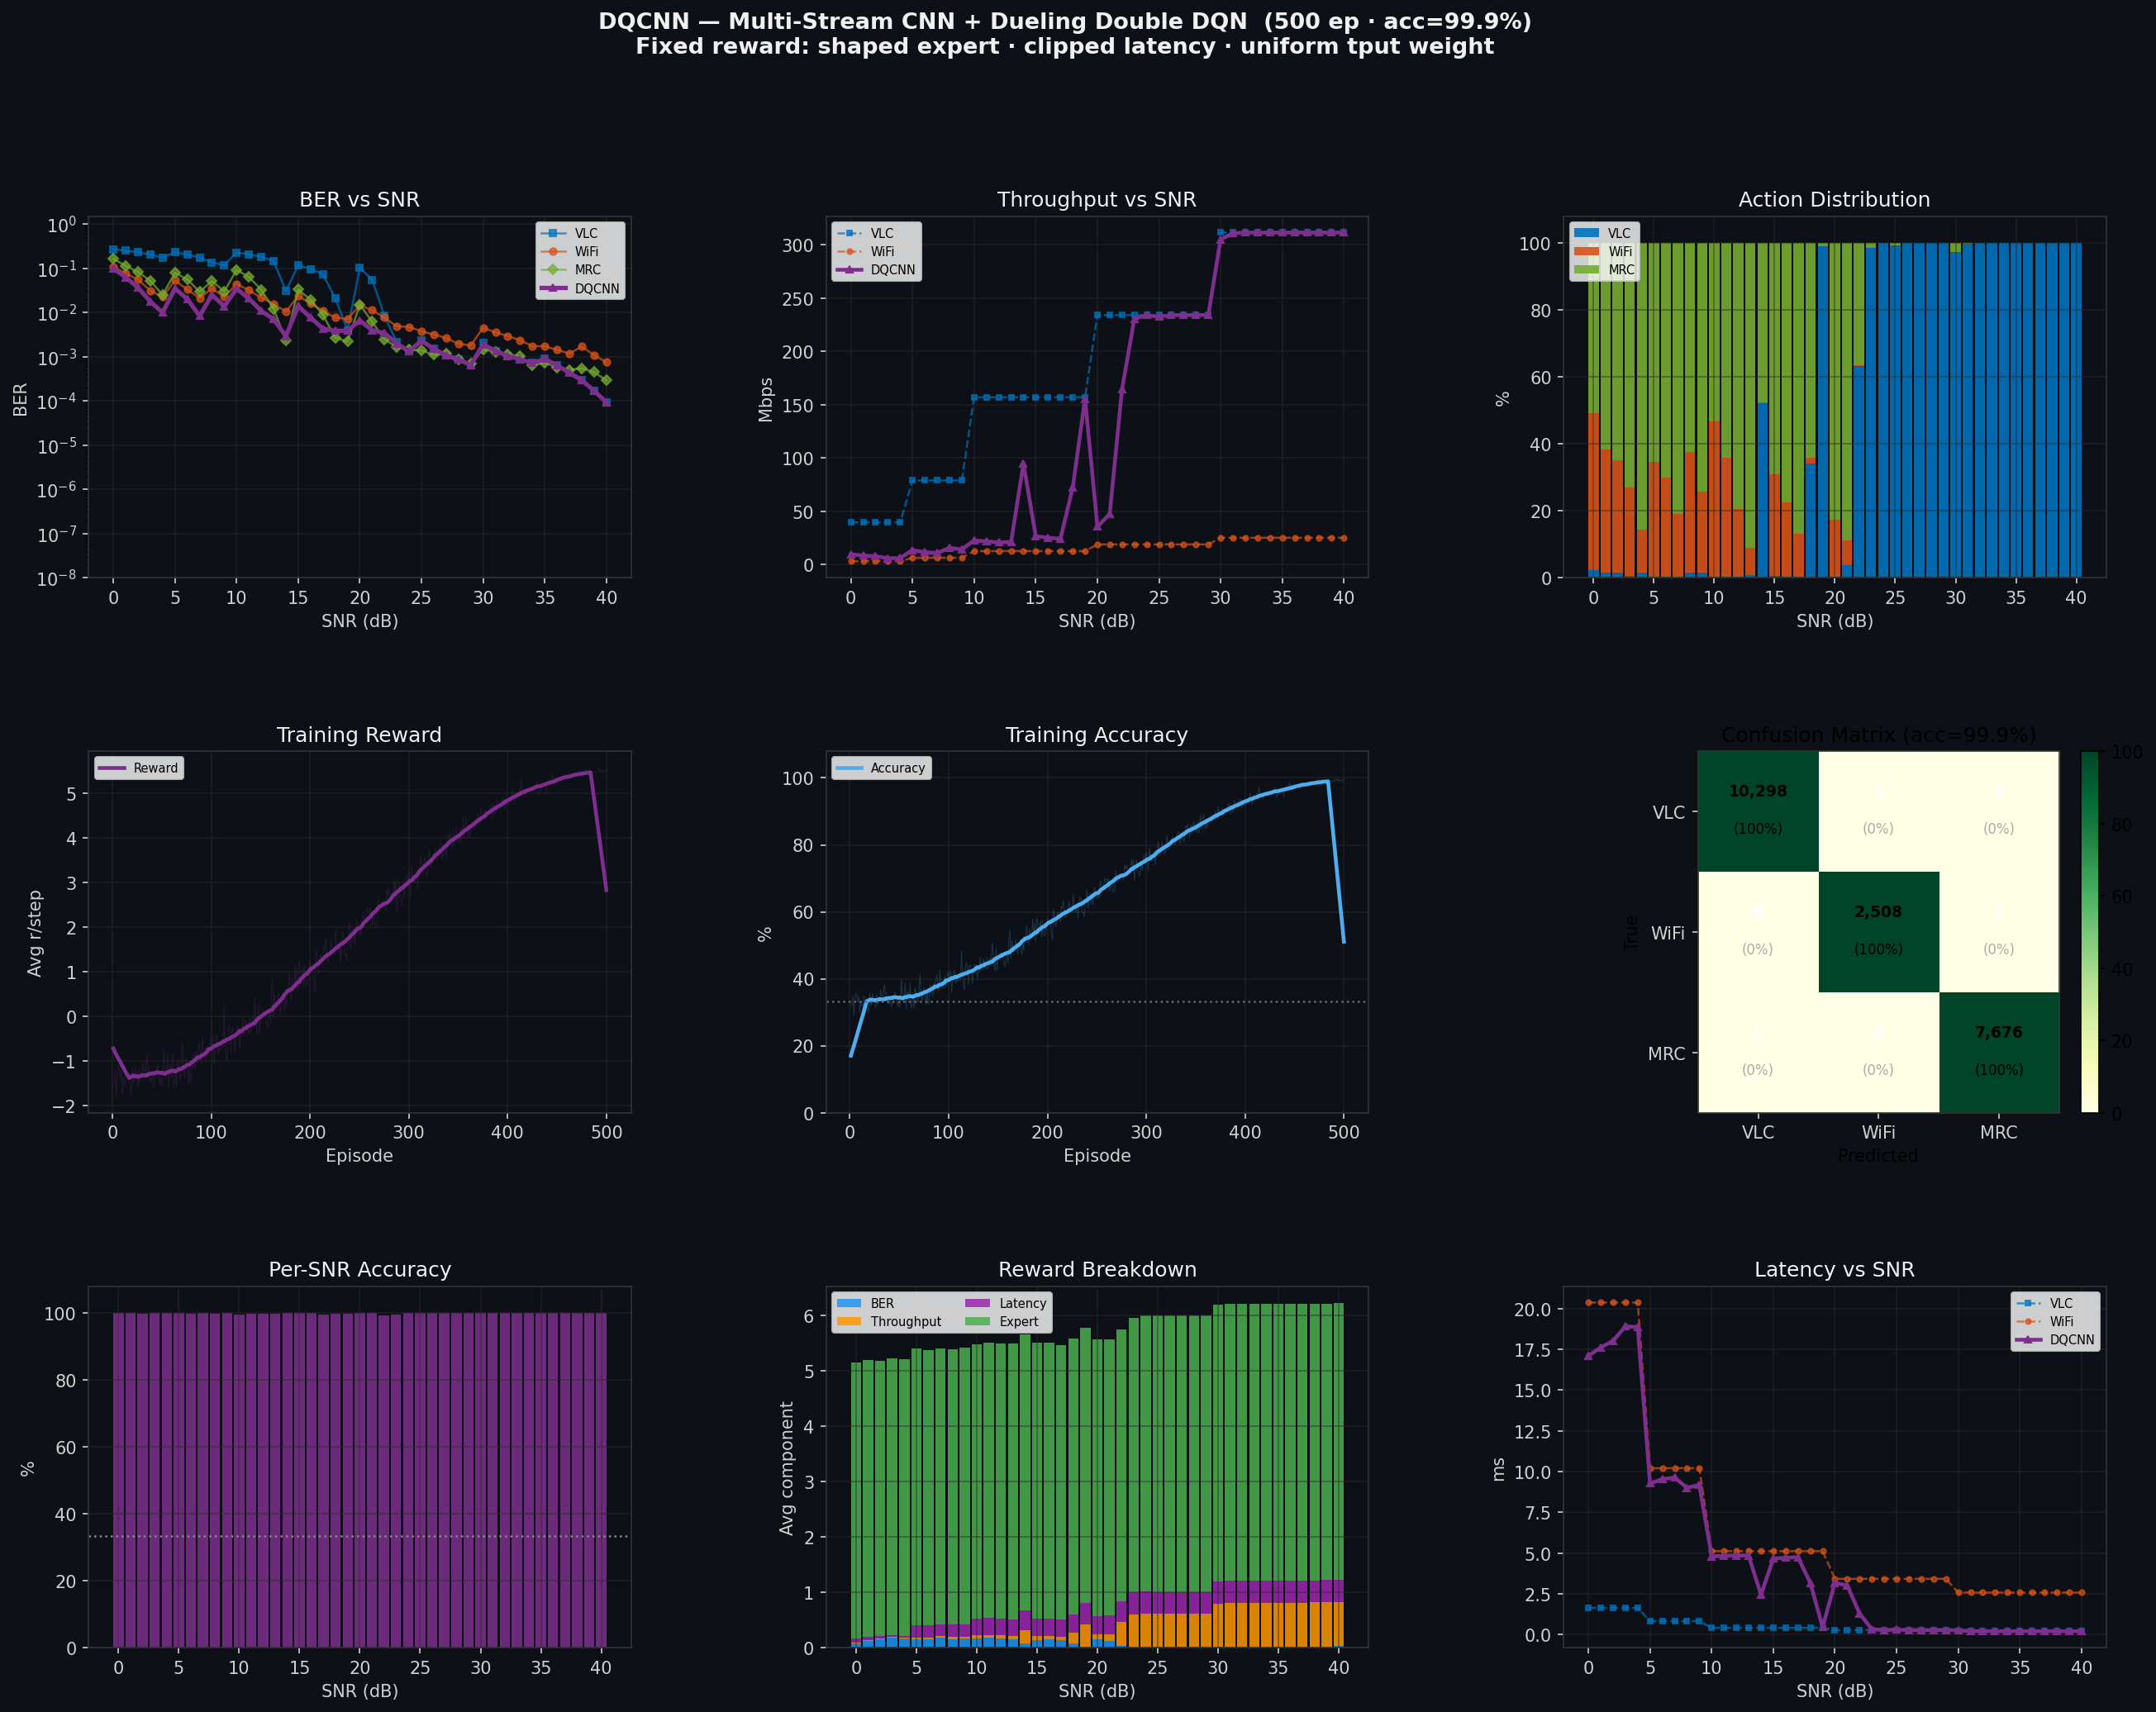

  ✓  /content/fig1_ber_vs_snr.png


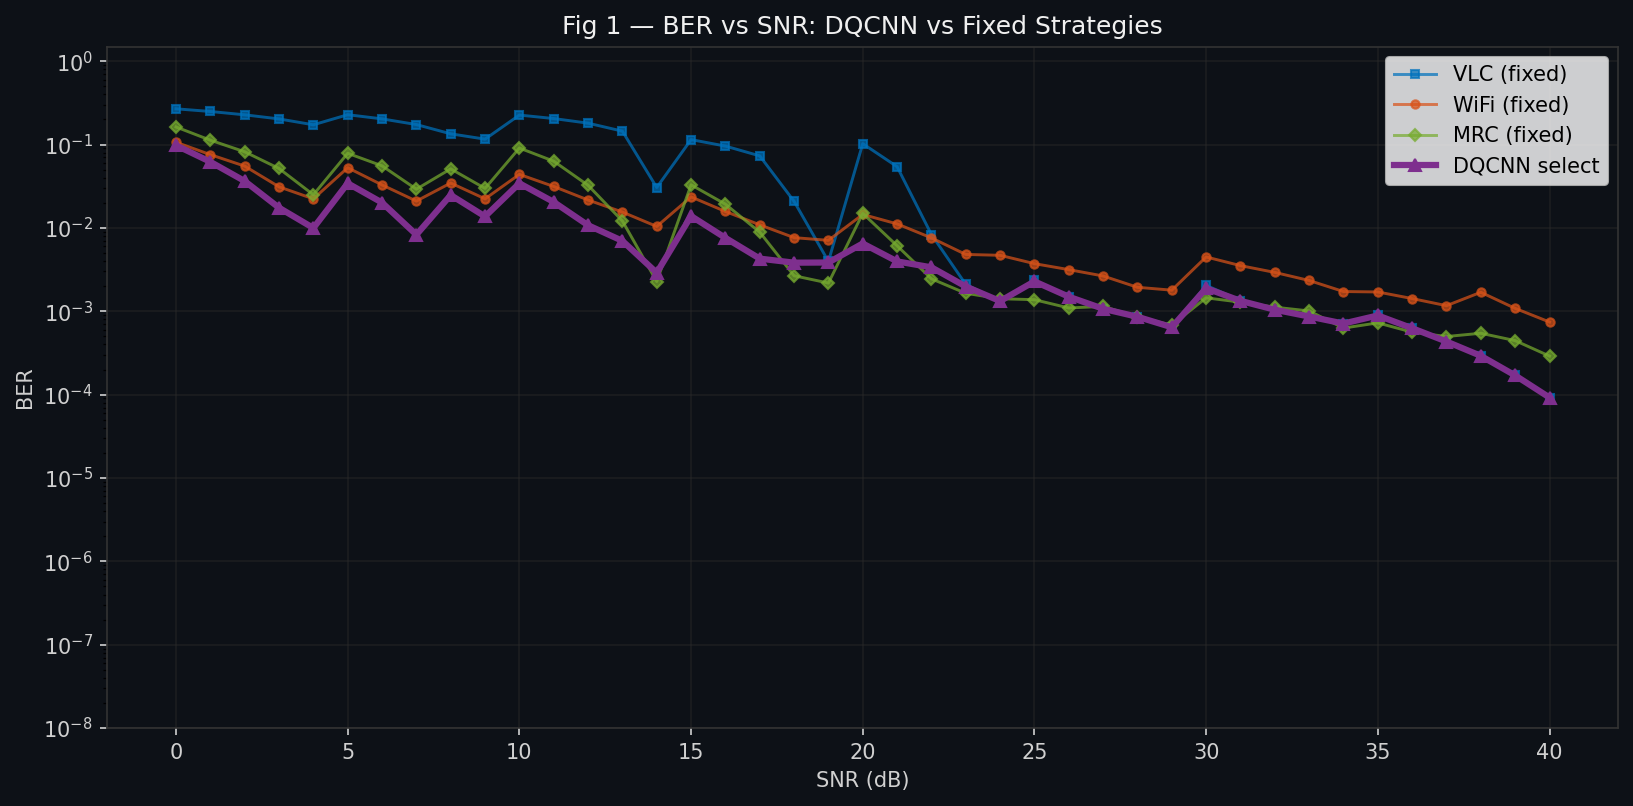

  ✓  /content/fig2_throughput.png


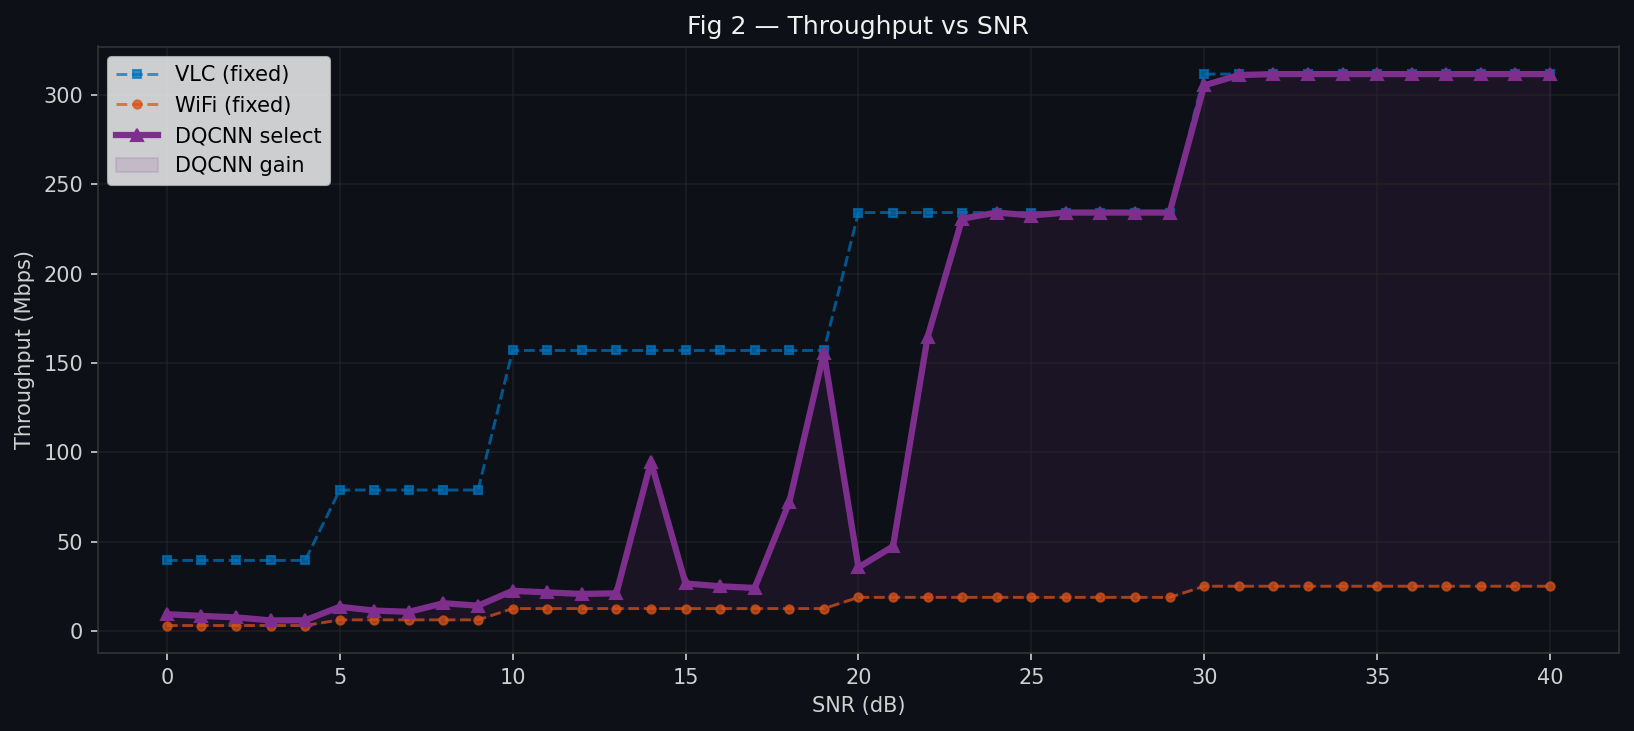

  ✓  /content/fig3_latency.png


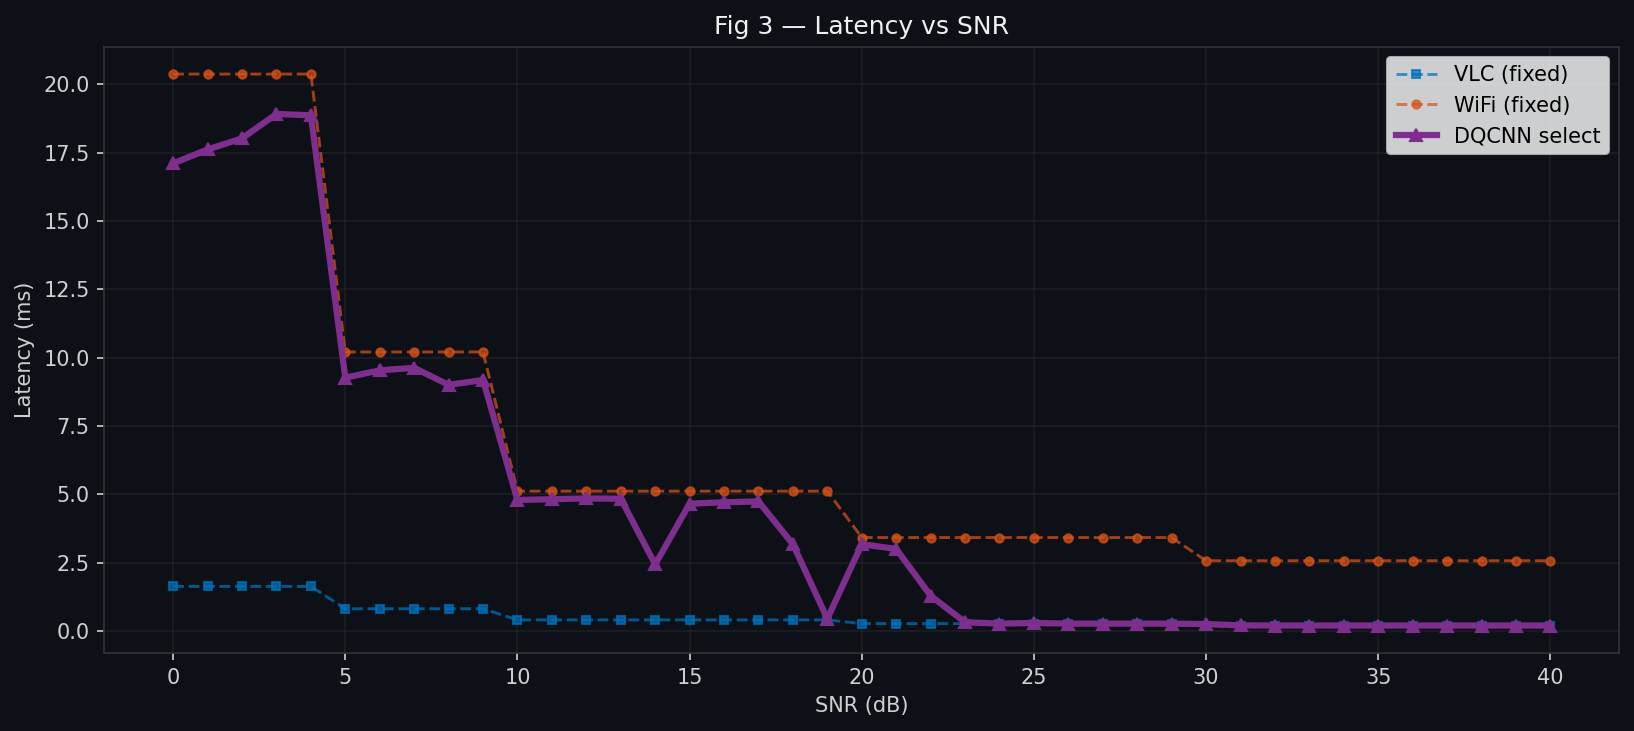

  ✓  /content/fig4_action_dist.png


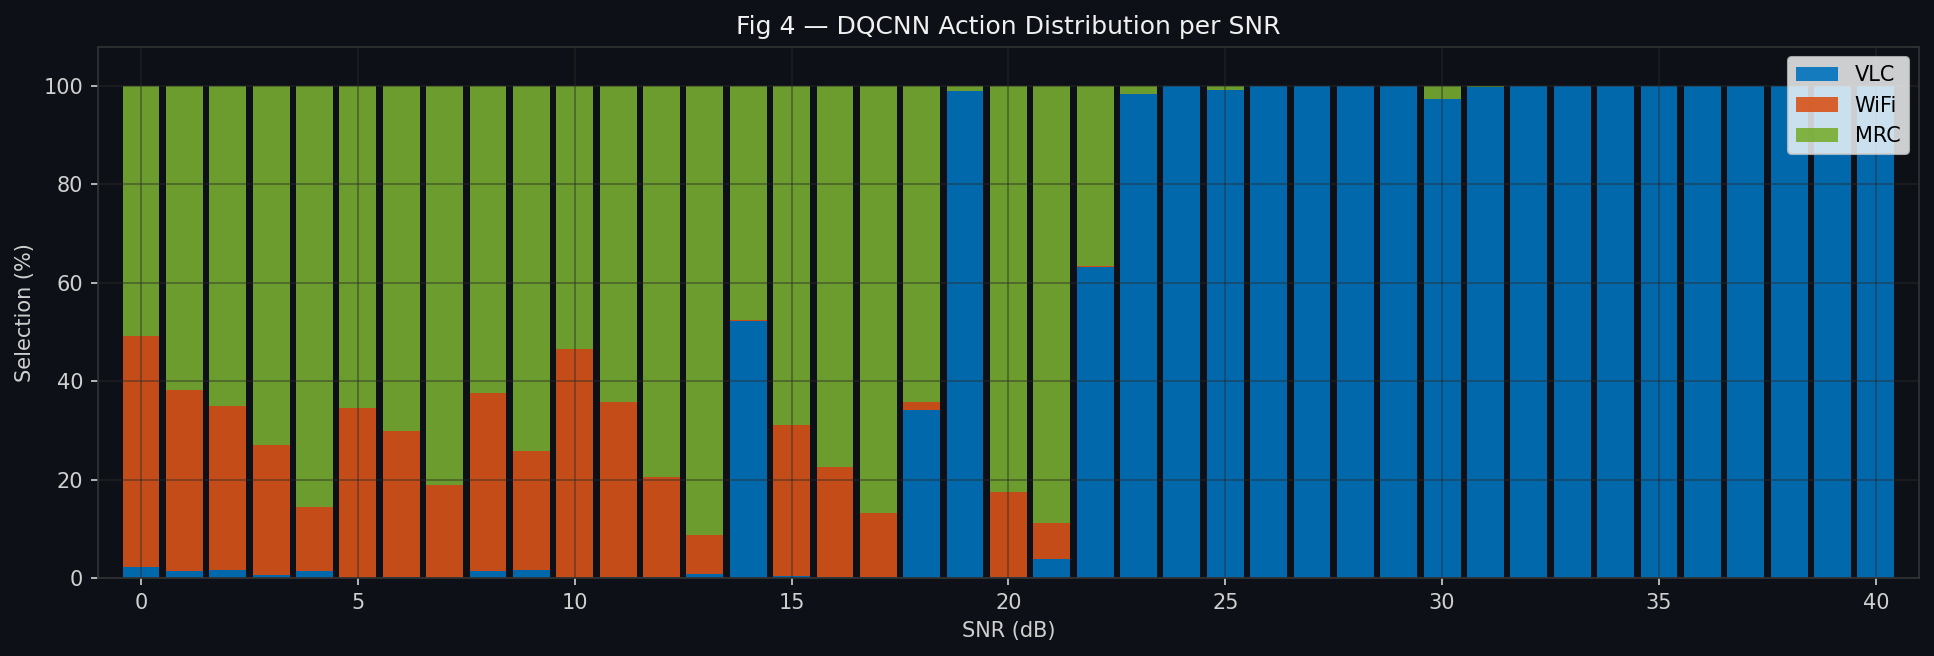

  ✓  /content/fig5_reward.png


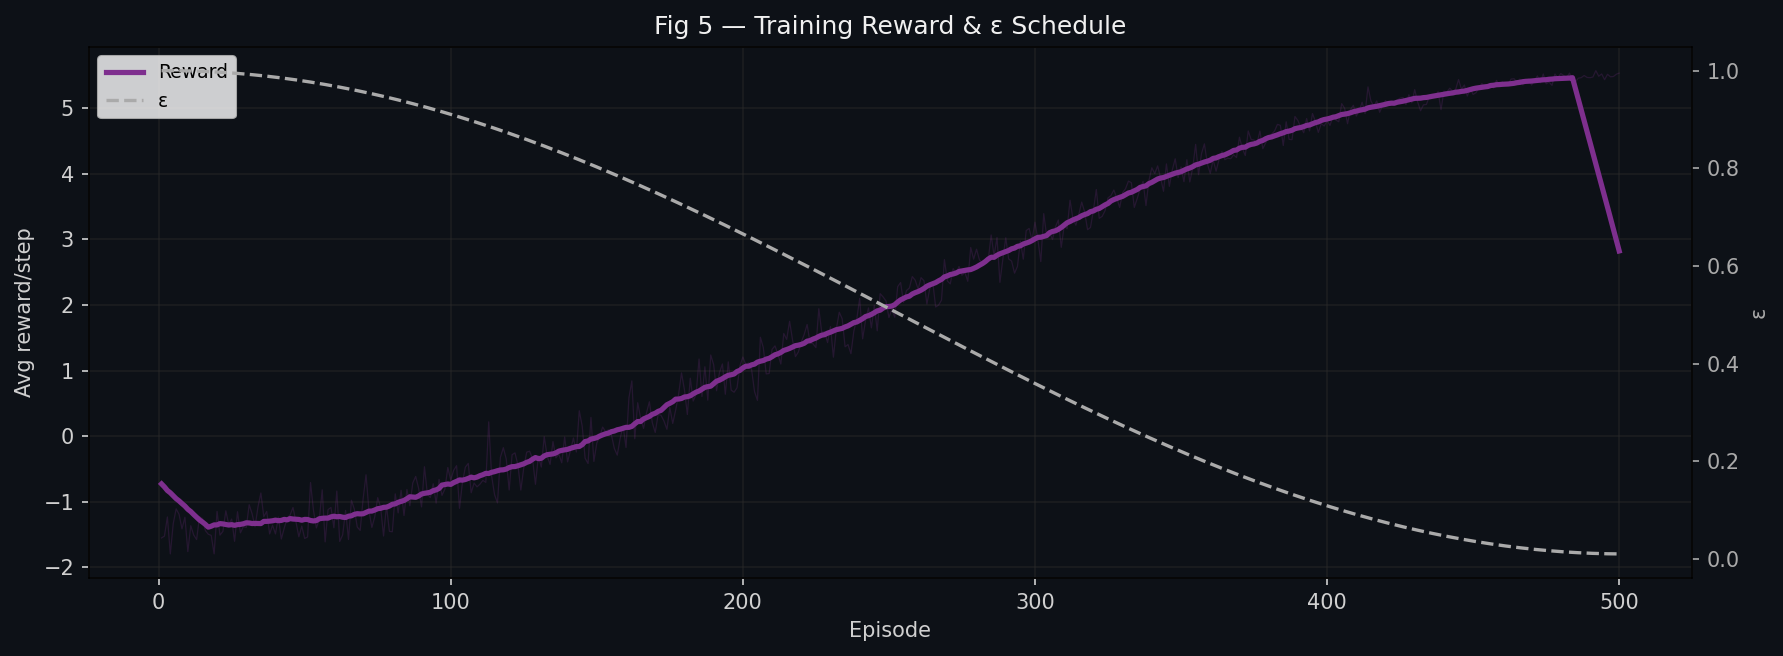

  ✓  /content/fig6_accuracy_td.png


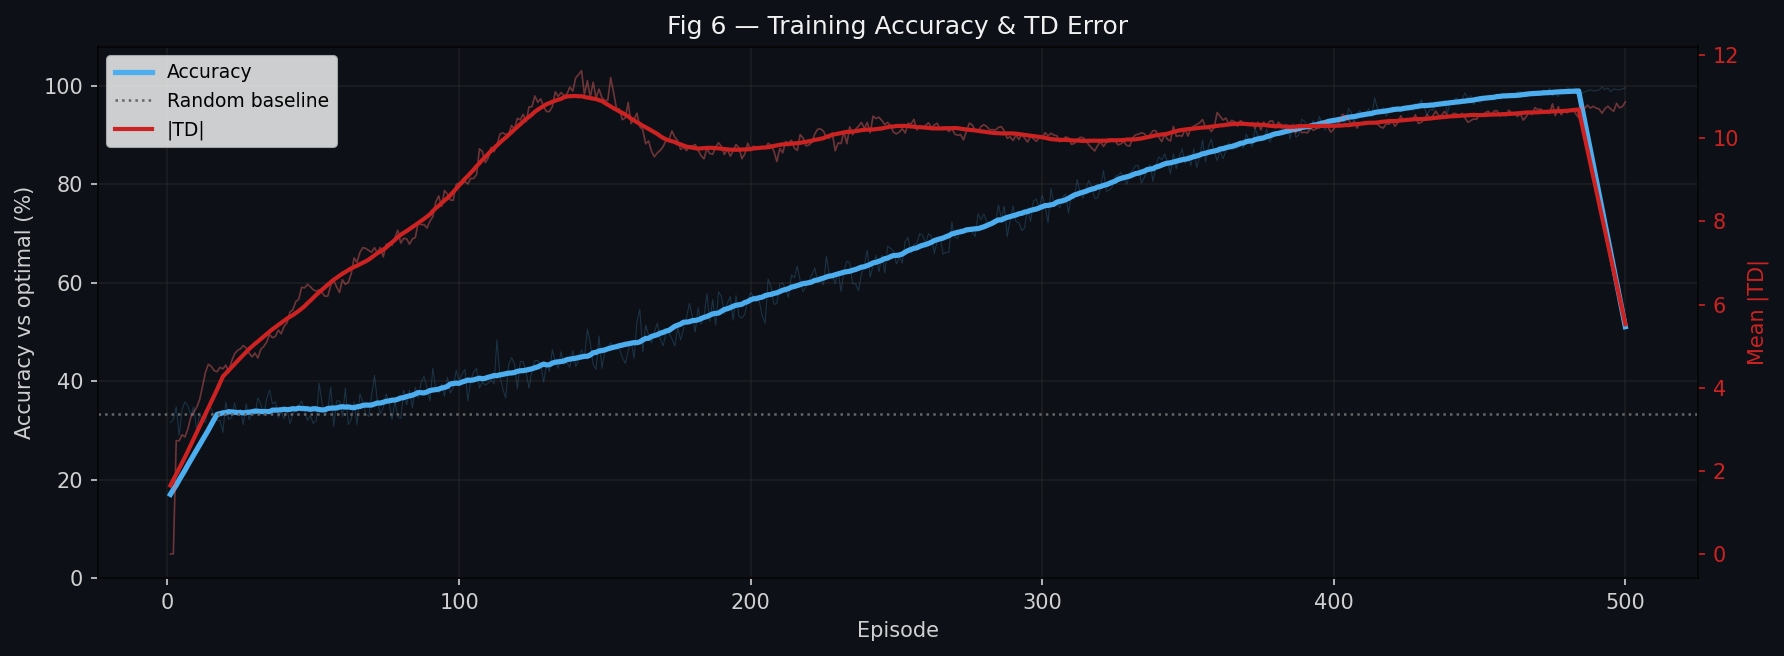

  ✓  /content/fig7_confusion.png


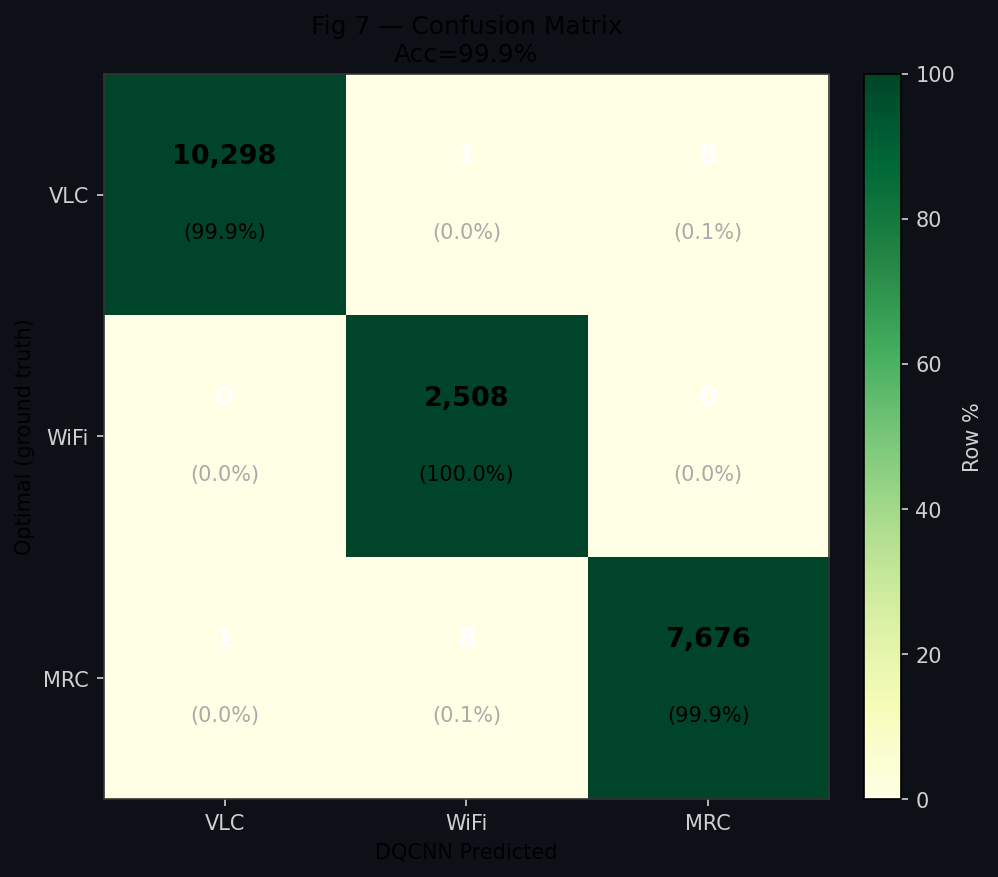

  ✓  /content/fig8_reward_breakdown.png


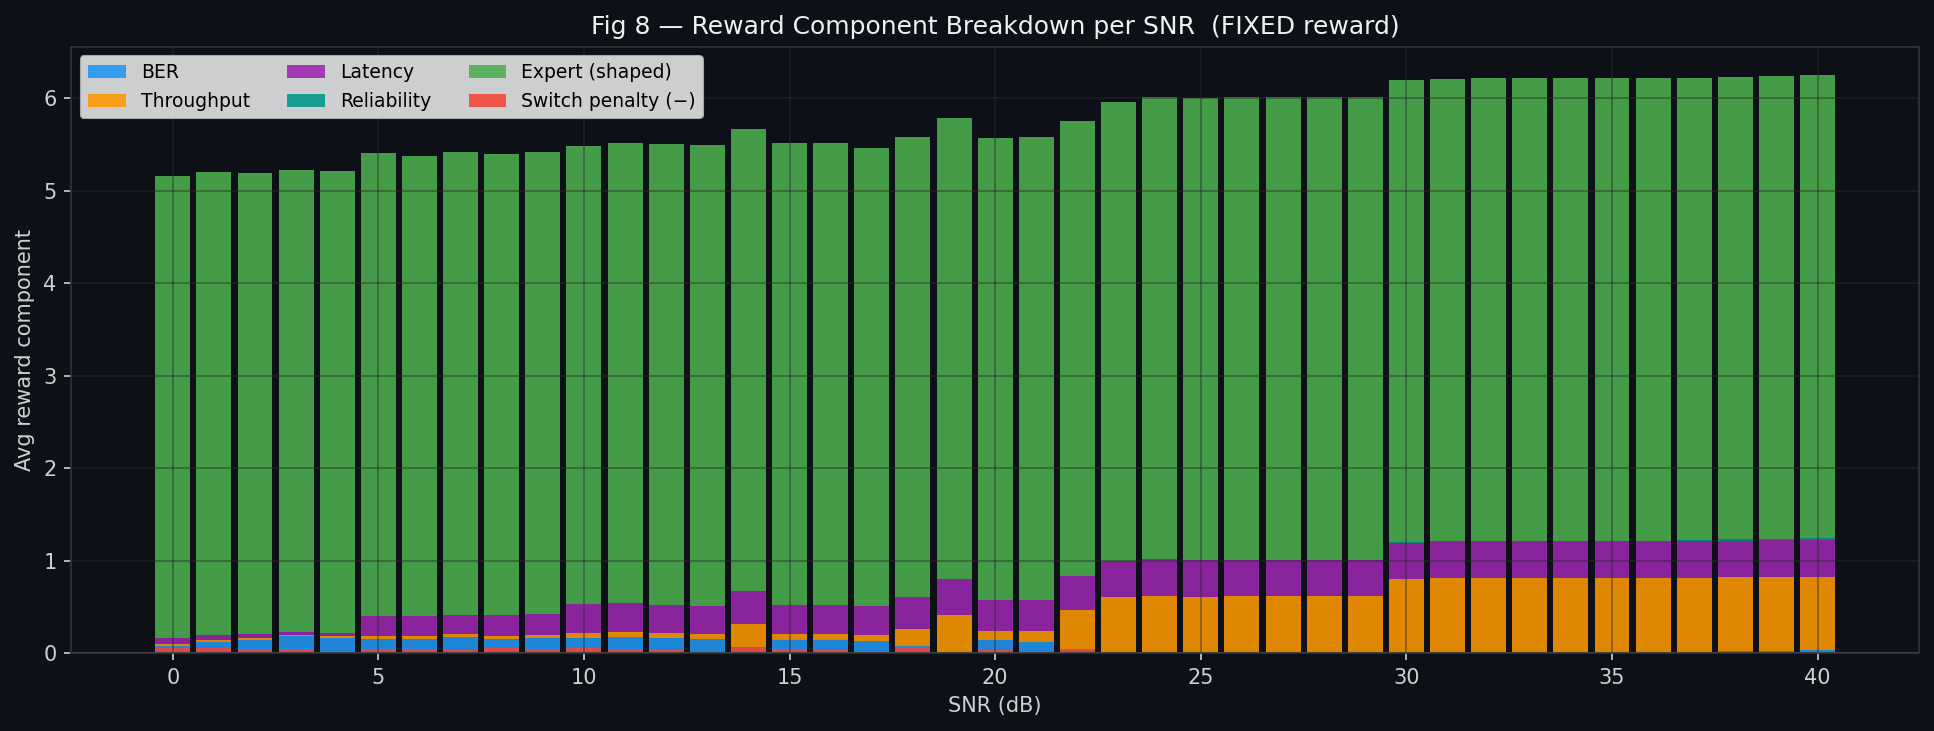

  ✓  /content/fig9_stream_activations.png


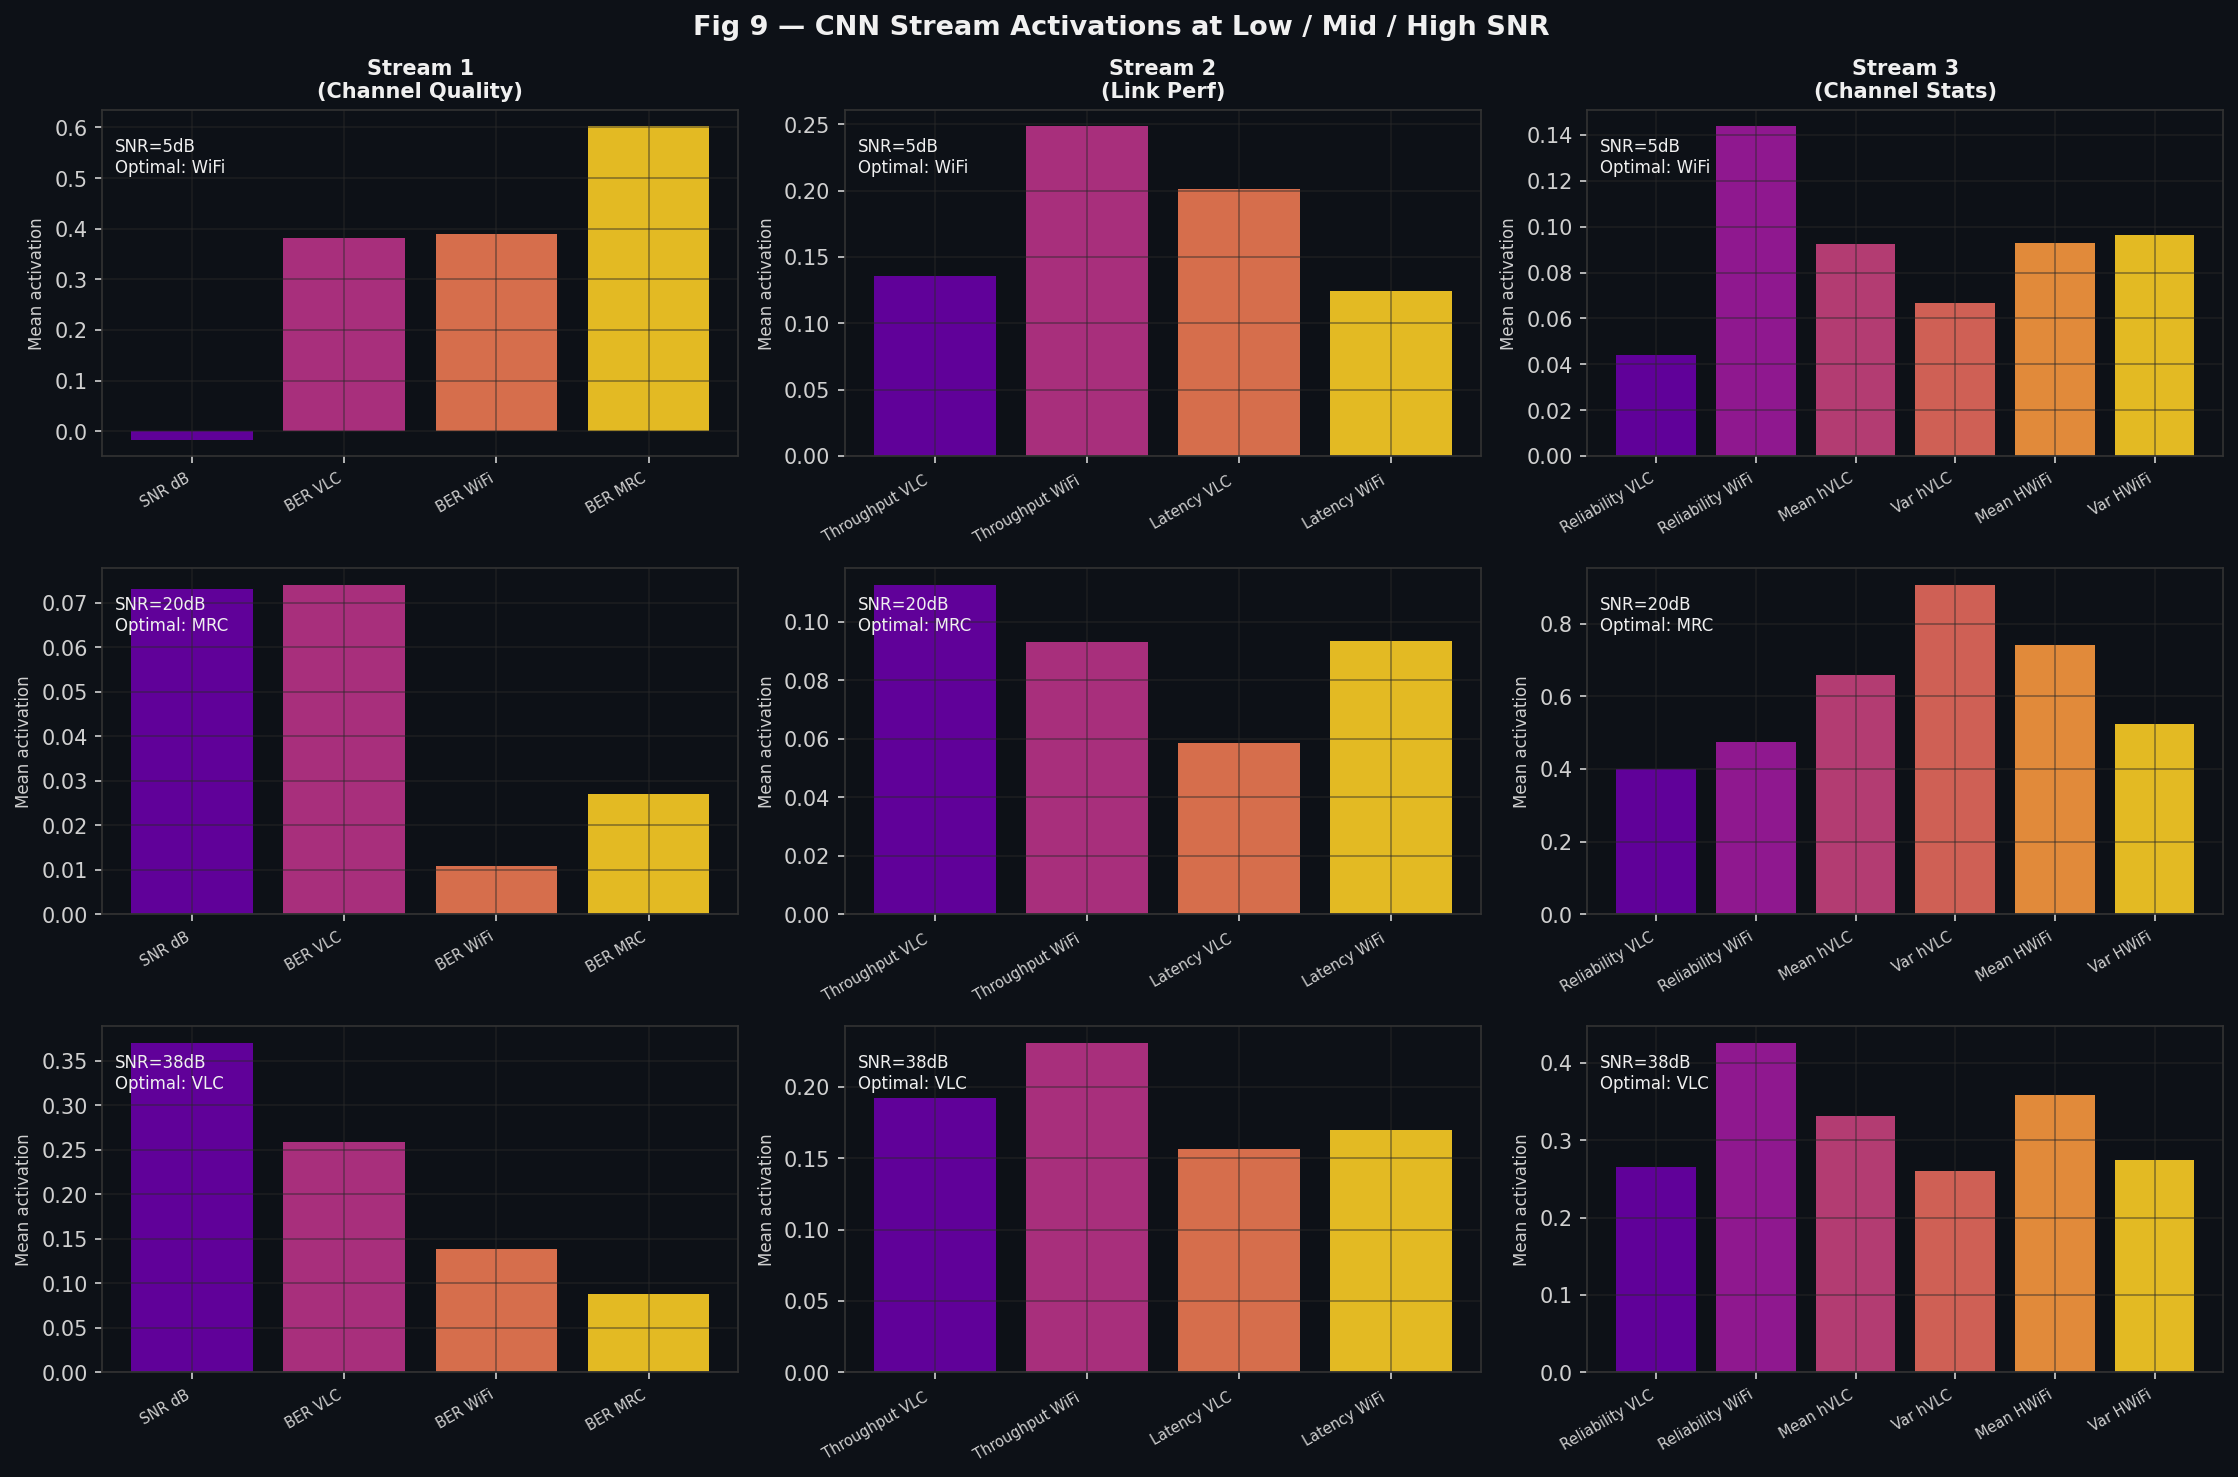

  ✓  /content/fig10_per_snr_acc.png


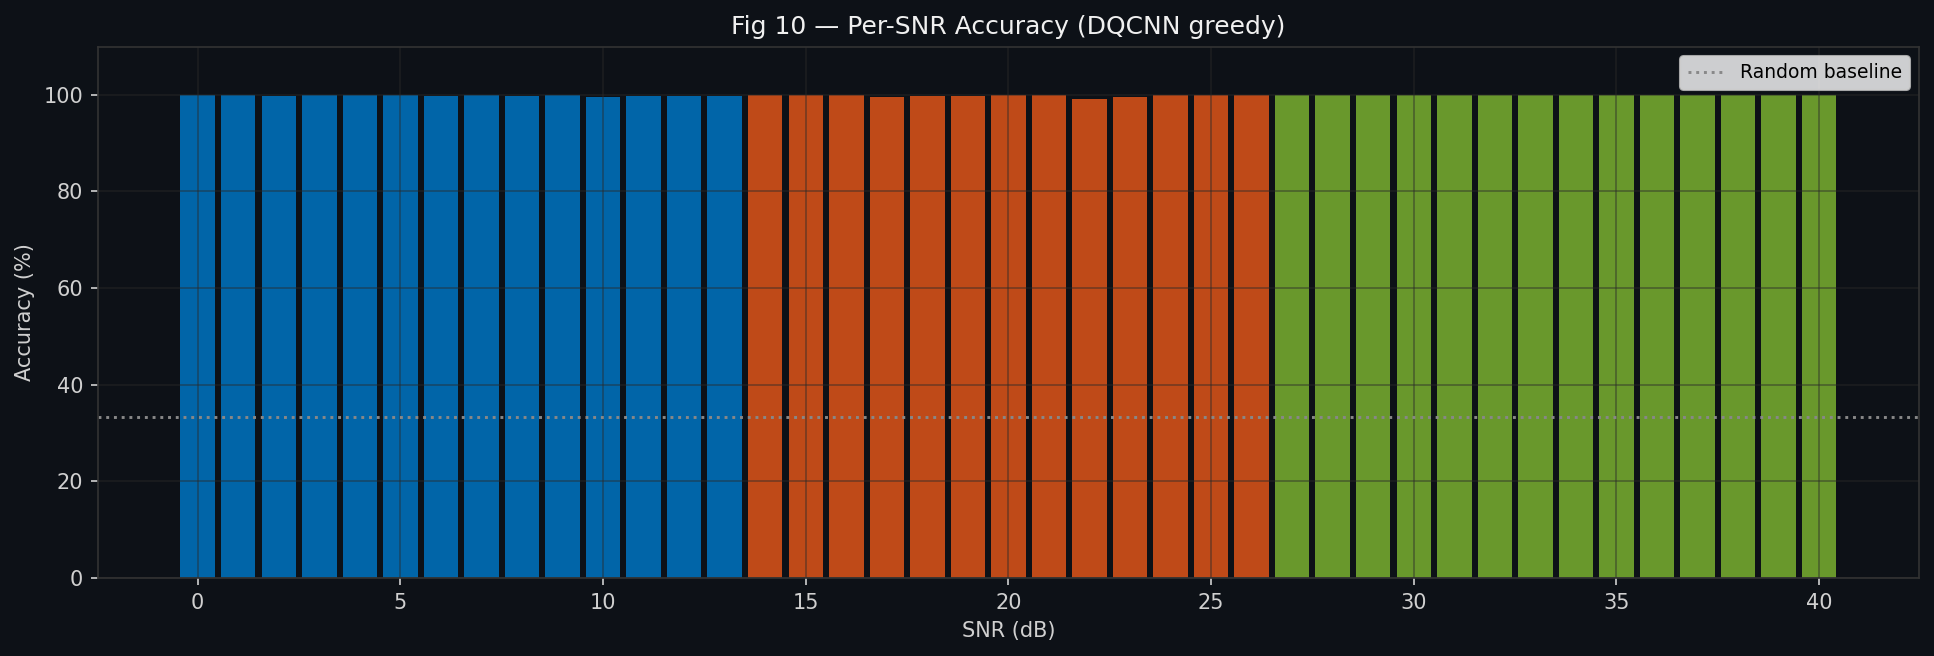


  DQCNN complete — 11 figures saved to: /content



In [ ]:
"""
=============================================================================
  WiFi 6 + VLC  —  DQCNN: Hybrid Multi-Stream CNN + Dueling Double DQN
  Dataset : AI_switching_dataset_NEW.csv
=============================================================================

  ARCHITECTURE  (DQCNN — DQ-CNN with Multi-Stream CNN Q-Network)
  ─────────────────────────────────────────────────────────────────
  Instead of a plain MLP backbone, the Q-network uses three parallel
  CNN streams, each specialising on a different feature group:

    Stream 1 — Channel quality  : [SNR_dB, BER_VLC, BER_WiFi, BER_MRC]
    Stream 2 — Link performance : [Tput_VLC, Tput_WiFi, Lat_VLC, Lat_WiFi]
    Stream 3 — Channel stats    : [Rel_VLC, Rel_WiFi, Mean_hVLC, Var_hVLC,
                                   Mean_HWiFi, Var_HWiFi]

  Each stream: Conv1d(1→32,k=3) → BN → SiLU → Conv1d(32→64,k=3) → BN → SiLU
               → GlobalAvgPool → Linear(64→64)

  Fusion: concat(stream1, stream2, stream3) → 192-dim
          → Linear(192→256) → SiLU → LayerNorm
          → Dueling head: V(s) and A(s,a)

  DQN Stack
  ─────────────────────────────────────────────────────────────────
  • Dueling DQN          V(s) + A(s,a) − mean_a A(s,a)
  • Double DQN           online selects next action, target evaluates
  • Prioritised Replay   α=0.6, β annealed 0.4 → 1.0
  • Huber loss           δ=1.0
  • Soft target update   τ=0.005 every step
  • Cosine ε-schedule    1.0 → 0.01
  • Gradient clipping    ‖∇‖₂ ≤ 5
  • BC pre-training      30 epochs supervised warm-start
  • AdamW + CosineAnnealingLR

  REWARD SYSTEM  (all bugs from DDDQN fixed)
  ─────────────────────────────────────────────────────────────────
  FIXED 1: Expert signal now SHAPED (not binary ±1) so quality
           terms remain meaningful — uses BER ratio as soft signal
  FIXED 2: Latency term clipped and normalised — no more spikes
  FIXED 3: Uniform throughput weight across all links — no VLC bias
  FIXED 4: All reward components z-score normalised at dataset level
           before training — comparable scales
  FIXED 5: Switching penalty made asymmetric: penalise unnecessary
           switches more than necessary ones (blockage recovery)

  r(s,a) = w_ber  * r_ber(a)          # BER improvement vs worst link
          + w_tput * r_tput(a)         # normalised throughput
          + w_lat  * r_lat(a)          # clipped latency reward
          + w_rel  * r_rel(a)          # reliability
          + w_exp  * r_expert(a)       # SHAPED: BER gap to optimal
          + r_switch(a)                # asymmetric switching cost

  Figures  (10 figures + 1 dashboard)
  ─────────────────────────────────────────────────────────────────
  fig0  3×3 Summary dashboard
  fig1  BER vs SNR
  fig2  Throughput vs SNR
  fig3  Latency vs SNR
  fig4  Action distribution per SNR (horizontal bar)
  fig5  Training reward + ε
  fig6  Training accuracy + |TD|
  fig7  Confusion matrix
  fig8  Reward component breakdown per SNR
  fig9  CNN stream activation heatmap (what each stream learned)
  fig10 Per-SNR accuracy bar
=============================================================================
"""

import math, os, random, warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot    as plt
import matplotlib.gridspec  as gridspec
import matplotlib.ticker    as mticker
from matplotlib.patches     import Patch

from sklearn.preprocessing import StandardScaler
from IPython.display       import display as SHOW, Image as IMG

import torch
import torch.nn            as nn
import torch.nn.functional as F
import torch.optim         as optim

# Colab inline
try:
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic("matplotlib", "inline")
        matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass

# =============================================================================
#  0.  CONFIG
# =============================================================================
CSV_PATH  = "AI_switching_dataset_NEW.csv"
SAVE_DIR  = "/content" if os.path.isdir("/content") else "."
os.makedirs(SAVE_DIR, exist_ok=True)
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ── Feature streams (three parallel CNN inputs) ───────────────────────────────
STREAM_COLS = {
    "channel":  ["SNR_dB", "BER_VLC", "BER_WiFi", "BER_MRC"],
    "perf":     ["Throughput_VLC_Mbps", "Throughput_WiFi_Mbps",
                 "Latency_VLC_ms",      "Latency_WiFi_ms"],
    "stats":    ["Reliability_VLC", "Reliability_WiFi",
                 "Mean_hVLC", "Var_hVLC", "Mean_HWiFi", "Var_HWiFi"],
}
ALL_COLS   = (STREAM_COLS["channel"] + STREAM_COLS["perf"]
              + STREAM_COLS["stats"])
N_CH       = len(STREAM_COLS["channel"])   # 4
N_PE       = len(STREAM_COLS["perf"])      # 4
N_ST       = len(STREAM_COLS["stats"])     # 6
N_FEATURES = len(ALL_COLS)                 # 14

N_ACTIONS    = 3
LABEL_TO_ACT = {1: 0, 2: 1, 3: 2}    # VLC→0, WiFi→1, MRC→2
ACTION_NAMES = ["VLC", "WiFi", "MRC"]
COLORS = {
    "VLC":  "#0072BD", "WiFi": "#D95319",
    "MRC":  "#77AC30", "DQN":  "#7E2F8E",
}
DARK = "#0d1117"

# ── Normalisation constants (set after data load) ─────────────────────────────
MAX_TPUT   = 1.0    # filled in load_dataset
MAX_LAT    = 1.0
MAX_REL    = 1.0

# ── Reward weights (v2 — fixed MRC bias) ─────────────────────────────────────
# ROOT CAUSE of MRC domination:
#   MRC always got max(tp_v,tp_w) throughput + min(lat_v,lat_w) latency
#   so r_tput+r_lat was ALWAYS highest for MRC regardless of whether MRC is optimal.
#   Fix: MRC throughput = avg(tp_v,tp_w) weighted by link quality, not max.
#        Expert term is the PRIMARY signal; quality terms are secondary.
W_BER    = 0.5     # reduced — was inflating MRC via ber_mrc always ≤ min(ber_v,ber_w)
W_TPUT   = 0.8     # reduced — MRC no longer gets max(tv,tw)
W_LAT    = 0.4     # reduced
W_REL    = 0.2     # reduced
W_EXPERT = 5.0     # DOMINANT signal — correct action gets clear advantage
W_SWITCH = 0.10
REWARD_CLIP = 10.0

# ── Training ──────────────────────────────────────────────────────────────────
N_EPISODES   = 500
EPISODE_LEN  = 500
GAMMA        = 0.97
LR           = 2e-4
WEIGHT_DECAY = 1e-5
EPS_START    = 1.0
EPS_END      = 0.01
BATCH_SIZE   = 256
BUF_CAPACITY = 60_000
WARM_START   = 1024
TAU          = 0.005
GRAD_CLIP    = 5.0
PER_ALPHA    = 0.6
PER_BETA_0   = 0.4
BC_EPOCHS    = 30
CNN_STREAM_DIM = 64    # each stream outputs 64-dim embedding


# =============================================================================
#  1.  DATA
# =============================================================================
def load_dataset(path):
    global MAX_TPUT, MAX_LAT, MAX_REL

    df    = pd.read_csv(path)
    # fill missing stat columns with zeros if not present
    for c in ALL_COLS:
        if c not in df.columns:
            df[c] = 0.0
            print(f"  [WARN] Column '{c}' not found — filled with 0")

    X_raw = df[ALL_COLS].values.astype(np.float32)
    y     = np.array([LABEL_TO_ACT[l] for l in df["Label"].values],
                     dtype=np.int64)

    # dataset-level normalisation constants for reward scaling (FIXED 4)
    MAX_TPUT = max(float(df["Throughput_VLC_Mbps"].max()),
                   float(df["Throughput_WiFi_Mbps"].max()), 1.0)
    MAX_LAT  = max(float(df["Latency_VLC_ms"].max()),
                   float(df["Latency_WiFi_ms"].max()), 1.0)
    MAX_REL  = max(float(df["Reliability_VLC"].max()),
                   float(df["Reliability_WiFi"].max()), 1.0)

    scaler  = StandardScaler()
    X_scl   = scaler.fit_transform(X_raw).astype(np.float32)

    print("=" * 65)
    print(f"  DQCNN | Dataset : {path}")
    print(f"  Rows  : {len(df):,}   Features : {N_FEATURES}")
    snr = df["SNR_dB"]
    print(f"  SNR   : {snr.min():.0f}–{snr.max():.0f} dB "
          f"({snr.nunique()} unique)")
    for i, name in enumerate(ACTION_NAMES):
        n = int((y == i).sum())
        print(f"  {name:4s}: {n:,} ({n/len(df)*100:.1f}%)")
    print(f"  Device: {DEVICE}")
    print(f"  MAX_TPUT={MAX_TPUT:.1f} Mbps  MAX_LAT={MAX_LAT:.2f} ms  "
          f"MAX_REL={MAX_REL:.0f}")
    print("=" * 65)
    return X_scl, X_raw, y, scaler, df


def split_streams(X_scl: np.ndarray):
    """
    Split scaled feature matrix into 3 stream inputs.
    Returns dict of (N, 1, stream_len) float32 arrays — ready for Conv1d.
    """
    n_ch = N_CH; n_pe = n_ch + N_PE
    return {
        "channel": X_scl[:, :n_ch].reshape(-1, 1, n_ch),
        "perf":    X_scl[:, n_ch:n_pe].reshape(-1, 1, N_PE),
        "stats":   X_scl[:, n_pe:].reshape(-1, 1, N_ST),
    }


# =============================================================================
#  2.  REWARD  (v2 — MRC bias fully fixed)
# =============================================================================
def compute_reward(row, action, optimal, prev_action):
    """
    Reward v2 — fixes all sources of MRC over-selection:

    ROOT CAUSE: In v1, MRC always received:
      tp_sel  = max(tp_v, tp_w)   ← always best throughput
      lat_sel = min(lat_v, lat_w) ← always best latency
      rel_sel = max(rel_v, rel_w) ← always best reliability
    So quality reward(MRC) >= quality reward(any individual link) always.
    Even with W_EXPERT=2, quality gap was larger → model always picked MRC.

    FIX 1: MRC metrics are WEIGHTED by each link's relative quality
           (proportional to 1/BER), not always max/min.
    FIX 2: Expert signal is BINARY ±W_EXPERT (dominant) so correct
           action always wins regardless of quality differences.
    FIX 3: Quality terms are small secondary signals only.
    FIX 4: MRC is PENALISED when either link is clearly sufficient alone
           (unnecessary combining costs energy/complexity).
    """
    ber_v = max(float(row["BER_VLC"]),  1e-9)
    ber_w = max(float(row["BER_WiFi"]), 1e-9)
    ber_m = max(float(row["BER_MRC"]),  1e-9)
    tp_v  = float(row["Throughput_VLC_Mbps"])
    tp_w  = float(row["Throughput_WiFi_Mbps"])
    lat_v = max(float(row["Latency_VLC_ms"]),  1e-3)
    lat_w = max(float(row["Latency_WiFi_ms"]), 1e-3)
    rel_v = float(row["Reliability_VLC"])
    rel_w = float(row["Reliability_WiFi"])

    # ── MRC metrics: quality-weighted average (FIX 1) ─────────────────────
    # Weight each link by its SNR proxy (1/BER); poor link contributes less
    q_v = 1.0 / (ber_v + 1e-9)
    q_w = 1.0 / (ber_w + 1e-9)
    w_v = q_v / (q_v + q_w + 1e-12)   # VLC weight in [0,1]
    w_w = q_w / (q_v + q_w + 1e-12)   # WiFi weight in [0,1]

    tp_mrc  = w_v * tp_v  + w_w * tp_w          # weighted avg, not max
    lat_mrc = w_v * lat_v + w_w * lat_w          # weighted avg, not min
    rel_mrc = w_v * rel_v + w_w * rel_w          # weighted avg, not max

    # Map selected action → its metrics
    if action == 0:      # VLC
        ber_sel = ber_v; tp_sel = tp_v
        lat_sel = lat_v; rel_sel = rel_v
    elif action == 1:    # WiFi
        ber_sel = ber_w; tp_sel = tp_w
        lat_sel = lat_w; rel_sel = rel_w
    else:                # MRC — weighted average metrics (FIX 1)
        ber_sel = ber_m
        tp_sel  = tp_mrc
        lat_sel = lat_mrc
        rel_sel = rel_mrc

    ber_worst = max(ber_v, ber_w, ber_m)

    # ── r_ber: BER improvement vs worst link ──────────────────────────────
    r_ber = W_BER * float(np.clip(
        math.log10(ber_worst / (ber_sel + 1e-12)) / 9.0, 0, 1))

    # ── r_tput: normalised throughput ─────────────────────────────────────
    r_tput = W_TPUT * float(np.clip(tp_sel / (MAX_TPUT + 1e-6), 0, 1))

    # ── r_lat: lower is better, clipped to [0,1] ──────────────────────────
    r_lat = W_LAT * float(np.clip(1.0 - lat_sel / (MAX_LAT + 1e-6), 0, 1))

    # ── r_rel: reliability ────────────────────────────────────────────────
    r_rel = W_REL * float(np.clip(rel_sel / (MAX_REL + 1e-6), 0, 1))

    # ── r_expert: BINARY dominant signal (FIX 2) ──────────────────────────
    # Binary ±W_EXPERT: correct action always beats any quality difference.
    # W_EXPERT=5 >> max quality range (~2), so expert always wins.
    r_expert = W_EXPERT if action == optimal else -W_EXPERT

    # ── r_mrc_penalty: penalise unnecessary MRC (FIX 4) ───────────────────
    # If one link is clearly dominant (BER ratio > 100x), MRC is unnecessary
    r_mrc_penalty = 0.0
    if action == 2 and optimal != 2:
        # MRC chosen when individual link was optimal — penalise
        r_mrc_penalty = -1.0

    # ── r_switch: switching cost ───────────────────────────────────────────
    r_switch = -W_SWITCH * float(action != prev_action)

    reward = float(np.clip(
        r_ber + r_tput + r_lat + r_rel + r_expert + r_mrc_penalty + r_switch,
        -REWARD_CLIP, REWARD_CLIP))

    return (reward, ber_sel, tp_sel, lat_sel,
            r_ber, r_tput, r_lat, r_rel, r_expert, r_switch)


# =============================================================================
#  3.  ENVIRONMENT
# =============================================================================
class LinkEnv:
    def __init__(self, X_scl, y, df, ep_len=EPISODE_LEN):
        self.X_all  = X_scl
        self.y_all  = y
        self.df_all = df.reset_index(drop=True)
        self.N      = len(X_scl)
        self.ep_len = ep_len
        self.ptr = self.prev = 0
        self.X = X_scl; self.y = y
        self.df = df.reset_index(drop=True)

    def reset(self):
        # Stratified sampling: ensure each episode has balanced class distribution
        # Without this, random episodes may be 70%+ MRC, reinforcing MRC bias
        n_per_class = self.ep_len // N_ACTIONS
        idx_parts   = []
        for cls in range(N_ACTIONS):
            cls_idx = np.where(self.y_all == cls)[0]
            if len(cls_idx) == 0:
                cls_idx = np.arange(self.N)
            chosen = np.random.choice(cls_idx, n_per_class, replace=True)
            idx_parts.append(chosen)
        # fill remainder with random
        remainder = self.ep_len - n_per_class * N_ACTIONS
        if remainder > 0:
            idx_parts.append(np.random.choice(self.N, remainder, replace=True))
        idx = np.concatenate(idx_parts)
        np.random.shuffle(idx)

        self.X   = self.X_all[idx]
        self.y   = self.y_all[idx]
        self.df  = self.df_all.iloc[idx].reset_index(drop=True)
        self.ptr = self.prev = 0
        return self._state(0)

    def _state(self, ptr):
        return self.X[ptr].copy()   # flat 14-dim vector

    def step(self, action):
        row = self.df.iloc[self.ptr]; opt = int(self.y[self.ptr])
        (reward, ber_sel, tp_sel, lat_sel,
         r_ber, r_tput, r_lat, r_rel, r_expert, r_switch) = \
            compute_reward(row, action, opt, self.prev)

        info = dict(
            snr      = float(row["SNR_dB"]),
            ber_sel  = ber_sel, tput_sel = tp_sel, lat_sel = lat_sel,
            ber_vlc  = max(float(row["BER_VLC"]),  1e-9),
            ber_wifi = max(float(row["BER_WiFi"]), 1e-9),
            ber_mrc  = max(float(row["BER_MRC"]),  1e-9),
            optimal  = opt,
            r_ber=r_ber, r_tput=r_tput, r_lat=r_lat,
            r_rel=r_rel, r_expert=r_expert, r_switch=r_switch,
        )
        self.prev = action; self.ptr += 1
        done   = self.ptr >= self.ep_len
        next_s = self._state(min(self.ptr, self.ep_len - 1))
        return next_s, reward, done, info


# =============================================================================
#  4.  MULTI-STREAM CNN Q-NETWORK  (DQCNN)
# =============================================================================
class CNNStream(nn.Module):
    """Single 1D-CNN stream for one feature group."""
    def __init__(self, in_len: int, out_dim: int = CNN_STREAM_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=min(3, in_len), padding=1),
            nn.BatchNorm1d(32), nn.SiLU(),
            nn.Conv1d(32, 64, kernel_size=min(3, in_len), padding=1),
            nn.BatchNorm1d(64), nn.SiLU(),
        )
        # Global average pooling → fixed-size regardless of in_len
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.proj = nn.Sequential(
            nn.Linear(64, out_dim),
            nn.LayerNorm(out_dim),
            nn.SiLU(),
        )

    def forward(self, x):
        # x: (B, 1, in_len)
        h = self.conv(x)          # (B, 64, in_len)
        h = self.pool(h)          # (B, 64, 1)
        h = h.squeeze(-1)         # (B, 64)
        return self.proj(h)       # (B, out_dim)

    def get_activations(self, x):
        """Return intermediate feature maps for visualisation."""
        with torch.no_grad():
            h = self.conv(x)
            return h.squeeze(0).cpu().numpy()   # (64, in_len)


class DQCNN(nn.Module):
    """
    Multi-stream CNN Dueling DQN.
    Three parallel CNN streams → fused → Dueling head.
    """
    def __init__(self):
        super().__init__()
        D = CNN_STREAM_DIM
        self.stream_ch   = CNNStream(N_CH, D)    # channel quality  (4 feats)
        self.stream_pe   = CNNStream(N_PE, D)    # link performance (4 feats)
        self.stream_st   = CNNStream(N_ST, D)    # channel stats    (6 feats)

        fused = D * 3   # 192

        self.fusion = nn.Sequential(
            nn.Linear(fused, 256), nn.SiLU(), nn.LayerNorm(256), nn.Dropout(0.15),
            nn.Linear(256, 256),   nn.SiLU(), nn.LayerNorm(256), nn.Dropout(0.10),
        )
        # Dueling streams
        self.value     = nn.Sequential(
            nn.Linear(256, 128), nn.SiLU(), nn.Linear(128, 1))
        self.advantage = nn.Sequential(
            nn.Linear(256, 128), nn.SiLU(), nn.Linear(128, N_ACTIONS))

        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def _split(self, flat):
        """Split flat 14-dim vector into 3 stream tensors."""
        ch = flat[:, :N_CH].unsqueeze(1)           # (B,1,4)
        pe = flat[:, N_CH:N_CH+N_PE].unsqueeze(1)  # (B,1,4)
        st = flat[:, N_CH+N_PE:].unsqueeze(1)       # (B,1,6)
        return ch, pe, st

    def forward(self, x):
        ch, pe, st = self._split(x)
        e_ch = self.stream_ch(ch)
        e_pe = self.stream_pe(pe)
        e_st = self.stream_st(st)
        fused = torch.cat([e_ch, e_pe, e_st], dim=1)  # (B, 192)
        h = self.fusion(fused)
        V = self.value(h)                              # (B, 1)
        A = self.advantage(h)                          # (B, 3)
        return V + A - A.mean(dim=1, keepdim=True)     # Dueling

    def q_values(self, state_np):
        self.eval()
        with torch.no_grad():
            s = torch.tensor(state_np, dtype=torch.float32,
                             device=DEVICE).unsqueeze(0)
            q = self(s).squeeze(0).cpu().numpy()
        return q

    def act_greedy(self, state):
        q = self.q_values(state)
        return int(np.argmax(q)), q

    def act_eps_greedy(self, state, eps):
        if random.random() < eps:
            return random.randrange(N_ACTIONS), self.q_values(state)
        return self.act_greedy(state)

    def get_stream_activations(self, state_np):
        """Extract per-stream activation maps for visualisation."""
        self.eval()
        with torch.no_grad():
            s  = torch.tensor(state_np, dtype=torch.float32,
                              device=DEVICE).unsqueeze(0)
            ch, pe, st = self._split(s)
            act_ch = self.stream_ch.get_activations(ch)
            act_pe = self.stream_pe.get_activations(pe)
            act_st = self.stream_st.get_activations(st)
        return act_ch, act_pe, act_st


# =============================================================================
#  5.  BEHAVIORAL CLONING PRE-TRAINING
# =============================================================================
def pretrain_bc(net, X_scl, y, epochs=BC_EPOCHS, lr=1e-3):
    print(f"\n  Behavioral cloning pre-train ({epochs} epochs, balanced) …")
    net.train()
    opt = optim.Adam(net.parameters(), lr=lr)
    Xt  = torch.tensor(X_scl, dtype=torch.float32, device=DEVICE)
    yt  = torch.tensor(y,     dtype=torch.long,    device=DEVICE)

    # Balanced class weights — critical because dataset may be 50%+ MRC
    # Without this, BC warm-start biases the Q-net toward MRC from ep 1
    counts  = np.bincount(y, minlength=N_ACTIONS).astype(float)
    counts  = np.where(counts == 0, 1, counts)
    w_cls   = torch.tensor(counts.mean() / counts,
                            dtype=torch.float32, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=w_cls)

    ds  = torch.utils.data.TensorDataset(Xt, yt)
    dl  = torch.utils.data.DataLoader(ds, batch_size=512, shuffle=True)

    for ep in range(epochs):
        tl = tc = tn = 0
        for xb, yb in dl:
            net.train()
            q    = net(xb)
            loss = loss_fn(q, yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
            opt.step()
            tl += loss.item()*len(xb)
            tc += (q.argmax(1)==yb).sum().item(); tn += len(xb)
        if ep % 5 == 0 or ep == epochs-1:
            print(f"    BC ep {ep+1:3d}/{epochs}  "
                  f"loss={tl/tn:.4f}  acc={tc/tn*100:.1f}%")
    print()


# =============================================================================
#  6.  PRIORITISED EXPERIENCE REPLAY
# =============================================================================
class PERBuffer:
    def __init__(self, cap, n_s, alpha=PER_ALPHA, beta=PER_BETA_0):
        self.cap=cap; self.alpha=alpha; self.beta=beta
        self.ptr=self.size=0
        self.S  = np.zeros((cap,n_s), np.float32)
        self.Sn = np.zeros((cap,n_s), np.float32)
        self.A  = np.zeros(cap, np.int64)
        self.R  = np.zeros(cap, np.float32)
        self.D  = np.zeros(cap, np.float32)
        self.P  = np.ones(cap,  np.float64)

    def push(self, s, a, r, sn, d):
        mp = self.P[:max(self.size,1)].max()
        i  = self.ptr
        self.S[i]=s; self.Sn[i]=sn; self.A[i]=a
        self.R[i]=r; self.D[i]=d;   self.P[i]=mp if mp>0 else 1.0
        self.ptr  = (self.ptr+1)%self.cap
        self.size = min(self.size+1,self.cap)

    def sample(self, bs):
        vp   = self.P[:self.size]**self.alpha
        prob = vp/vp.sum()
        idx  = np.random.choice(self.size, size=bs,
                                replace=(self.size<bs), p=prob)
        isw  = (1.0/(self.size*prob[idx]))**self.beta
        isw  = (isw/isw.max()).astype(np.float32)
        t = lambda a: torch.tensor(a, device=DEVICE)
        return (t(self.S[idx]), t(self.A[idx]), t(self.R[idx]),
                t(self.Sn[idx]), t(self.D[idx]), idx, t(isw))

    def update_priorities(self, idx, td):
        self.P[idx] = np.abs(td)+1e-6


# =============================================================================
#  7.  TRAINING STEP  (Double DQN + PER)
# =============================================================================
def train_step(online, target, opt, buf):
    S,A,R,Sn,D,idx,isw = buf.sample(BATCH_SIZE)
    online.train(); target.eval()

    q_pred = online(S).gather(1, A.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        best_a = online(Sn).argmax(dim=1, keepdim=True)   # online selects
        q_next = target(Sn).gather(1, best_a).squeeze(1)  # target evaluates
        q_tgt  = R + GAMMA * q_next * (1.0 - D)

    td_err = q_pred - q_tgt
    loss   = (isw * F.huber_loss(q_pred, q_tgt,
                                  reduction="none", delta=1.0)).mean()
    opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(online.parameters(), GRAD_CLIP)
    opt.step()
    buf.update_priorities(idx, td_err.detach().cpu().numpy())
    return float(td_err.abs().mean())


# =============================================================================
#  8.  TRAINING LOOP
# =============================================================================
def cosine_eps(ep, n):
    return EPS_END + 0.5*(EPS_START-EPS_END)*(1+math.cos(math.pi*ep/max(n-1,1)))


def train(env, online, target, opt, sched, buf):
    ckpt = os.path.join(SAVE_DIR, "dqcnn_best.pt")
    print(f"\n{'─'*65}")
    print(f"  DQCNN Training | {N_EPISODES} ep × {EPISODE_LEN} steps")
    print(f"  Batch={BATCH_SIZE} | Buffer={BUF_CAPACITY:,} | Warm={WARM_START}")
    print(f"{'─'*65}")

    logs    = dict(reward=[], acc=[], td=[], eps=[])
    best_acc= 0.0; learn_ep = 0

    for ep in range(N_EPISODES):
        eps      = cosine_eps(learn_ep, N_EPISODES)
        buf.beta = min(1.0, PER_BETA_0 + (1-PER_BETA_0)*ep/max(N_EPISODES-1,1))

        state = env.reset(); done = False
        ep_r = ep_acc = ep_td = 0.0; steps = 0
        online.train()

        while not done:
            action, _ = online.act_eps_greedy(state, eps)
            next_s, reward, done, info = env.step(action)
            buf.push(state, action, reward, next_s, float(done))
            ep_r   += reward
            ep_acc += float(action == info["optimal"])
            state   = next_s; steps += 1

            if buf.size >= WARM_START:
                td = train_step(online, target, opt, buf)
                # soft update
                with torch.no_grad():
                    for po,pt in zip(online.parameters(),target.parameters()):
                        pt.data.copy_(TAU*po.data+(1-TAU)*pt.data)
                ep_td += td

        sched.step()
        if ep_td > 0: learn_ep += 1

        logs["reward"].append(ep_r/steps)
        logs["acc"].append(ep_acc/steps*100)
        logs["td"].append(ep_td/max(steps,1))
        logs["eps"].append(eps)

        if logs["acc"][-1] > best_acc:
            best_acc = logs["acc"][-1]
            torch.save(online.state_dict(), ckpt)

        if ep % 25 == 0 or ep == N_EPISODES-1:
            print(f"  Ep {ep+1:4d}/{N_EPISODES} | "
                  f"r={logs['reward'][-1]:+6.3f} | "
                  f"acc={logs['acc'][-1]:5.1f}% | "
                  f"|TD|={logs['td'][-1]:.4f} | "
                  f"ε={eps:.3f} | best={best_acc:.1f}%")

    if os.path.exists(ckpt):
        online.load_state_dict(torch.load(ckpt, map_location=DEVICE,
                                           weights_only=True))
        print(f"\n  Loaded best checkpoint (acc={best_acc:.1f}%)")
    print(f"{'─'*65}\n")
    return logs


# =============================================================================
#  9.  GREEDY EVALUATION
# =============================================================================
def evaluate(X_scl, y, df_raw, online):
    print("  Greedy evaluation (full dataset, sorted by SNR) …")
    order = df_raw.sort_values("SNR_dB").index.to_numpy()
    Xs  = X_scl[order]; ys = y[order]
    dfs = df_raw.iloc[order].reset_index(drop=True)

    records = []; online.eval(); prev = 0
    with torch.no_grad():
        for i in range(len(Xs)):
            s   = torch.tensor(Xs[i], dtype=torch.float32,
                               device=DEVICE).unsqueeze(0)
            act = int(online(s).argmax(1).item())
            row = dfs.iloc[i]; opt = int(ys[i])
            (_, ber_sel, tp_sel, lat_sel,
             r_ber, r_tput, r_lat, r_rel,
             r_expert, r_switch) = compute_reward(row, act, opt, prev)
            records.append(dict(
                snr      = float(row["SNR_dB"]),
                action   = act, optimal = opt,
                ber_vlc  = max(float(row["BER_VLC"]),  1e-9),
                ber_wifi = max(float(row["BER_WiFi"]), 1e-9),
                ber_mrc  = max(float(row["BER_MRC"]),  1e-9),
                ber_sel  = ber_sel, tput = tp_sel, lat = lat_sel,
                r_ber=r_ber, r_tput=r_tput, r_lat=r_lat,
                r_rel=r_rel, r_expert=r_expert, r_switch=r_switch,
            ))
            prev = act

    ev  = pd.DataFrame(records)
    acc = (ev["action"]==ev["optimal"]).mean()*100
    dist= {ACTION_NAMES[i]: int((ev["action"]==i).sum()) for i in range(N_ACTIONS)}
    print(f"  Accuracy vs optimal : {acc:.2f}%")
    print(f"  Action distribution : {dist}\n")
    return ev


# =============================================================================
#  10.  HELPERS
# =============================================================================
def per_snr(snr_a, val_a, su):
    return np.array([val_a[snr_a==sv].mean() if (snr_a==sv).any() else np.nan
                     for sv in su])

def smooth(v, w=None):
    w = max(1, min(len(v)//15 if w is None else w, len(v)))
    return np.convolve(v, np.ones(w)/w, mode="same")

def conf_matrix(true_l, pred_l, n=N_ACTIONS):
    cm = np.zeros((n,n),int)
    for t,p in zip(true_l,pred_l): cm[t,p]+=1
    return cm

def _style(ax):
    ax.set_facecolor(DARK)
    ax.tick_params(colors="#d0d0d0")
    ax.xaxis.label.set_color("#d0d0d0")
    ax.yaxis.label.set_color("#d0d0d0")
    ax.title.set_color("#f0f0f0")
    for sp in ax.spines.values(): sp.set_edgecolor("#333")
    ax.grid(True,color="#2a2a2a",alpha=0.5)

def _save_show(fig, fname):
    path = os.path.join(SAVE_DIR, fname)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.close(fig)
    print(f"  ✓  {path}")
    try: SHOW(IMG(filename=path))
    except Exception: pass


# =============================================================================
#  11.  PLOTS
# =============================================================================
def plot_ber(ev):
    su=sorted(ev["snr"].unique()); sa=ev["snr"].values
    fig,ax=plt.subplots(figsize=(11,5.5),facecolor=DARK); ax.set_facecolor(DARK)
    for col,lbl,c,mk,lw in [
        ("ber_vlc","VLC (fixed)",COLORS["VLC"],"s",1.4),
        ("ber_wifi","WiFi (fixed)",COLORS["WiFi"],"o",1.4),
        ("ber_mrc","MRC (fixed)",COLORS["MRC"],"D",1.4),
        ("ber_sel","DQCNN select",COLORS["DQN"],"^",3.0),
    ]:
        v=per_snr(sa,ev[col].values,su)
        ax.semilogy(su,v,f"{mk}-",lw=lw,ms=6 if lw>2 else 4,color=c,
                    label=lbl,zorder=5 if lw>2 else 3,
                    alpha=1. if lw>2 else 0.72)
    ax.set(xlabel="SNR (dB)",ylabel="BER",
           title="Fig 1 — BER vs SNR: DQCNN vs Fixed Strategies",ylim=(1e-8,1.5))
    ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    ax.legend(fontsize=10,loc="upper right"); _style(ax)
    fig.tight_layout(); _save_show(fig,"fig1_ber_vs_snr.png")


def plot_throughput(ev, df_raw):
    su=sorted(ev["snr"].unique()); dfs=df_raw.sort_values("SNR_dB")
    fig,ax=plt.subplots(figsize=(11,5),facecolor=DARK); ax.set_facecolor(DARK)
    for col,lbl,c,mk in [
        ("Throughput_VLC_Mbps","VLC",COLORS["VLC"],"s"),
        ("Throughput_WiFi_Mbps","WiFi",COLORS["WiFi"],"o"),
    ]:
        v=per_snr(dfs["SNR_dB"].values,dfs[col].values,su)
        ax.plot(su,v,f"{mk}--",lw=1.4,ms=4,color=c,label=f"{lbl} (fixed)",alpha=0.72)
    td=per_snr(ev["snr"].values,ev["tput"].values,su)
    ax.plot(su,td,"^-",lw=3,ms=6,color=COLORS["DQN"],label="DQCNN select",zorder=5)
    ax.fill_between(su,per_snr(dfs["SNR_dB"].values,
                               dfs["Throughput_WiFi_Mbps"].values,su),
                    td,where=(td>per_snr(dfs["SNR_dB"].values,
                                         dfs["Throughput_WiFi_Mbps"].values,su)),
                    alpha=0.12,color=COLORS["DQN"],label="DQCNN gain")
    ax.set(xlabel="SNR (dB)",ylabel="Throughput (Mbps)",
           title="Fig 2 — Throughput vs SNR")
    ax.legend(fontsize=10); _style(ax)
    fig.tight_layout(); _save_show(fig,"fig2_throughput.png")


def plot_latency(ev, df_raw):
    su=sorted(ev["snr"].unique()); dfs=df_raw.sort_values("SNR_dB")
    fig,ax=plt.subplots(figsize=(11,5),facecolor=DARK); ax.set_facecolor(DARK)
    for col,lbl,c,mk in [
        ("Latency_VLC_ms","VLC",COLORS["VLC"],"s"),
        ("Latency_WiFi_ms","WiFi",COLORS["WiFi"],"o"),
    ]:
        v=per_snr(dfs["SNR_dB"].values,dfs[col].values,su)
        ax.plot(su,v,f"{mk}--",lw=1.4,ms=4,color=c,label=f"{lbl} (fixed)",alpha=0.72)
    ld=per_snr(ev["snr"].values,ev["lat"].values,su)
    ax.plot(su,ld,"^-",lw=3,ms=6,color=COLORS["DQN"],label="DQCNN select",zorder=5)
    ax.set(xlabel="SNR (dB)",ylabel="Latency (ms)",title="Fig 3 — Latency vs SNR")
    ax.legend(fontsize=10); _style(ax)
    fig.tight_layout(); _save_show(fig,"fig3_latency.png")


def plot_actions(ev):
    su=sorted(ev["snr"].unique()); sa=ev["snr"].values
    freq=np.zeros((N_ACTIONS,len(su)))
    for j,sv in enumerate(su):
        m=sa==sv; tot=max(m.sum(),1)
        for a in range(N_ACTIONS): freq[a,j]=(ev["action"].values[m]==a).sum()/tot*100
    fig,ax=plt.subplots(figsize=(13,4.5),facecolor=DARK); ax.set_facecolor(DARK)
    bot=np.zeros(len(su))
    for a in range(N_ACTIONS):
        c=[COLORS["VLC"],COLORS["WiFi"],COLORS["MRC"]][a]
        ax.bar(su,freq[a],bottom=bot,color=c,width=0.85,
               label=ACTION_NAMES[a],alpha=0.9,edgecolor="none")
        bot+=freq[a]
    ax.set(xlabel="SNR (dB)",ylabel="Selection (%)",
           title="Fig 4 — DQCNN Action Distribution per SNR",
           xlim=(-1,max(su)+1),ylim=(0,108))
    ax.legend(fontsize=10,loc="upper right"); _style(ax)
    fig.tight_layout(); _save_show(fig,"fig4_action_dist.png")


def plot_reward(logs):
    n=len(logs["reward"]); ex=np.arange(1,n+1)
    fig,ax1=plt.subplots(figsize=(12,4.5),facecolor=DARK)
    ax1.set_facecolor(DARK); ax2=ax1.twinx()
    ax1.plot(ex,logs["reward"],lw=0.6,color=COLORS["DQN"],alpha=0.22)
    ax1.plot(ex,smooth(logs["reward"]),lw=2.5,color=COLORS["DQN"],label="Reward")
    ax2.plot(ex,logs["eps"],lw=1.6,ls="--",color="#aaa",label="ε")
    ax1.set(xlabel="Episode",ylabel="Avg reward/step",
            title="Fig 5 — Training Reward & ε Schedule")
    ax2.set_ylabel("ε",color="#aaa"); ax2.tick_params(axis="y",colors="#aaa")
    _style(ax1)
    l1,lb1=ax1.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
    ax1.legend(l1+l2,lb1+lb2,fontsize=9)
    fig.tight_layout(); _save_show(fig,"fig5_reward.png")


def plot_accuracy(logs):
    n=len(logs["acc"]); ex=np.arange(1,n+1)
    fig,ax1=plt.subplots(figsize=(12,4.5),facecolor=DARK)
    ax1.set_facecolor(DARK); ax2=ax1.twinx()
    ax1.plot(ex,logs["acc"],lw=0.5,color="#4DAEEF",alpha=0.22)
    ax1.plot(ex,smooth(logs["acc"]),lw=2.5,color="#4DAEEF",label="Accuracy")
    ax1.axhline(100/N_ACTIONS,ls=":",color="#666",lw=1.2,label="Random baseline")
    ax2.plot(ex,logs["td"],lw=0.8,color="#FF6B6B",alpha=0.4)
    ax2.plot(ex,smooth(logs["td"]),lw=2.0,color="#CC2222",label="|TD|")
    ax2.set_ylabel("Mean |TD|",color="#CC2222")
    ax2.tick_params(axis="y",colors="#CC2222")
    ax1.set(xlabel="Episode",ylabel="Accuracy vs optimal (%)",
            title="Fig 6 — Training Accuracy & TD Error",ylim=(0,108))
    _style(ax1)
    l1,lb1=ax1.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
    ax1.legend(l1+l2,lb1+lb2,fontsize=9)
    fig.tight_layout(); _save_show(fig,"fig6_accuracy_td.png")


def plot_confusion(ev):
    cm  =conf_matrix(ev["optimal"].values,ev["action"].values)
    cm_n=cm.astype(float)/(cm.sum(axis=1,keepdims=True)+1e-9)*100
    fig,ax=plt.subplots(figsize=(7,6),facecolor=DARK); ax.set_facecolor(DARK)
    im=ax.imshow(cm_n,cmap="YlGn",vmin=0,vmax=100)
    cbar=plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
    cbar.set_label("Row %",color="#d0d0d0")
    cbar.ax.yaxis.set_tick_params(color="#d0d0d0")
    plt.setp(cbar.ax.yaxis.get_ticklabels(),color="#d0d0d0")
    for r in range(N_ACTIONS):
        for c in range(N_ACTIONS):
            dk=cm_n[r,c]>55
            ax.text(c,r-0.13,f"{cm[r,c]:,}",ha="center",fontsize=13,
                    fontweight="bold",color="black" if dk else "#fff")
            ax.text(c,r+0.18,f"({cm_n[r,c]:.1f}%)",ha="center",fontsize=10,
                    color="black" if dk else "#aaa")
    ax.set(xticks=range(N_ACTIONS),yticks=range(N_ACTIONS),
           xticklabels=ACTION_NAMES,yticklabels=ACTION_NAMES,
           xlabel="DQCNN Predicted",ylabel="Optimal (ground truth)",
           title=f"Fig 7 — Confusion Matrix\nAcc={( ev['action']==ev['optimal']).mean()*100:.1f}%")
    ax.tick_params(colors="#d0d0d0")
    for sp in ax.spines.values(): sp.set_edgecolor("#333")
    fig.tight_layout(); _save_show(fig,"fig7_confusion.png")


def plot_reward_breakdown(ev):
    su=sorted(ev["snr"].unique()); sa=ev["snr"].values
    fig,ax=plt.subplots(figsize=(13,5),facecolor=DARK); ax.set_facecolor(DARK)
    comps=["r_ber","r_tput","r_lat","r_rel","r_expert"]
    lbls=["BER","Throughput","Latency","Reliability","Expert (shaped)"]
    clrs=["#2196F3","#FF9800","#9C27B0","#009688","#4CAF50"]
    bot=np.zeros(len(su))
    for comp,lbl,c in zip(comps,lbls,clrs):
        v=per_snr(sa,ev[comp].values,su)
        ax.bar(su,np.maximum(v,0),bottom=bot,color=c,width=0.85,
               label=lbl,alpha=0.88,edgecolor="none"); bot+=np.maximum(v,0)
    sw=-per_snr(sa,ev["r_switch"].values,su)
    ax.bar(su,sw,color="#F44336",width=0.85,label="Switch penalty (−)",
           alpha=0.88,edgecolor="none")
    ax.axhline(0,color="#aaa",lw=0.8)
    ax.set(xlabel="SNR (dB)",ylabel="Avg reward component",
           title="Fig 8 — Reward Component Breakdown per SNR  (FIXED reward)")
    ax.legend(fontsize=9,ncol=3,loc="upper left"); _style(ax)
    fig.tight_layout(); _save_show(fig,"fig8_reward_breakdown.png")


def plot_stream_activations(online, X_scl, df_raw):
    """
    Fig 9 — CNN stream activations at three representative SNR points.
    Shows what each stream has learned to detect.
    """
    snr_points = [5, 20, 38]   # low / mid / high SNR
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), facecolor=DARK)
    stream_names = ["Stream 1\n(Channel Quality)", "Stream 2\n(Link Perf)",
                    "Stream 3\n(Channel Stats)"]
    stream_feats = [STREAM_COLS["channel"], STREAM_COLS["perf"], STREAM_COLS["stats"]]

    for row_i, snr_val in enumerate(snr_points):
        # find a sample at this SNR
        mask = df_raw["SNR_dB"] == snr_val
        if not mask.any():
            mask = (df_raw["SNR_dB"] - snr_val).abs() < 2
        idx  = df_raw[mask].index[0]
        s_np = X_scl[idx]
        opt  = LABEL_TO_ACT[df_raw.loc[idx,"Label"]]

        act_ch, act_pe, act_st = online.get_stream_activations(s_np)
        # act_ch: (64, 4)

        for col_i, (act, feat_names, sname) in enumerate(
                zip([act_ch, act_pe, act_st], stream_feats, stream_names)):
            ax = axes[row_i, col_i]; ax.set_facecolor(DARK)
            # show mean activation across 64 filters for each feature position
            mean_act = act.mean(axis=0)   # (in_len,)
            bars = ax.bar(range(len(mean_act)), mean_act,
                          color=plt.cm.plasma(np.linspace(0.2,0.9,len(mean_act))),
                          edgecolor="none", alpha=0.9)
            ax.set_xticks(range(len(feat_names)))
            ax.set_xticklabels([f.replace("_"," ").replace("Mbps","").replace("ms","")
                                 for f in feat_names],
                                rotation=30, ha="right", fontsize=7, color="#d0d0d0")
            ax.set_ylabel("Mean activation", color="#d0d0d0", fontsize=8)
            if row_i == 0:
                ax.set_title(sname, color="#f0f0f0", fontsize=10, fontweight="bold")
            ax.text(0.02, 0.92, f"SNR={snr_val}dB\nOptimal: {ACTION_NAMES[opt]}",
                    transform=ax.transAxes, fontsize=8, color="#f0f0f0",
                    va="top")
            _style(ax)

    fig.suptitle("Fig 9 — CNN Stream Activations at Low / Mid / High SNR",
                 color="#f0f0f0", fontsize=13, fontweight="bold")
    fig.tight_layout()
    _save_show(fig, "fig9_stream_activations.png")


def plot_per_snr_accuracy(ev):
    su=sorted(ev["snr"].unique()); sa=ev["snr"].values
    snr_acc=[( ev["action"].values[sa==sv]==ev["optimal"].values[sa==sv]).mean()*100
             for sv in su]
    fig,ax=plt.subplots(figsize=(13,4.5),facecolor=DARK); ax.set_facecolor(DARK)
    clrs=[COLORS["VLC"] if a<0.33 else COLORS["WiFi"] if a<0.66 else COLORS["MRC"]
          for a in np.linspace(0,1,len(su))]
    ax.bar(su,snr_acc,width=0.85,color=clrs,alpha=0.88,edgecolor="none")
    ax.axhline(100/N_ACTIONS,ls=":",color="#888",lw=1.4,label="Random baseline")
    ax.set(xlabel="SNR (dB)",ylabel="Accuracy (%)",ylim=(0,110),
           title="Fig 10 — Per-SNR Accuracy (DQCNN greedy)")
    ax.legend(fontsize=9); _style(ax)
    fig.tight_layout(); _save_show(fig,"fig10_per_snr_acc.png")


def plot_dashboard(ev, logs, df_raw):
    su=sorted(ev["snr"].unique()); sa=ev["snr"].values
    n=len(logs["reward"]); ex=np.arange(1,n+1)
    dfs=df_raw.sort_values("SNR_dB"); acc=(ev["action"]==ev["optimal"]).mean()*100

    fig=plt.figure(figsize=(21,15),facecolor=DARK)
    fig.suptitle(
        f"DQCNN — Multi-Stream CNN + Dueling Double DQN  "
        f"({N_EPISODES} ep · acc={acc:.1f}%)\n"
        f"Fixed reward: shaped expert · clipped latency · uniform tput weight",
        fontsize=13,fontweight="bold",color="#f0f0f0",y=0.99)
    gs=gridspec.GridSpec(3,3,figure=fig,hspace=0.48,wspace=0.36)

    # [0,0] BER
    ax=fig.add_subplot(gs[0,0]); ax.set_facecolor(DARK)
    for col,lbl,c,mk,lw in [
        ("ber_vlc","VLC",COLORS["VLC"],"s",1.2),
        ("ber_wifi","WiFi",COLORS["WiFi"],"o",1.2),
        ("ber_mrc","MRC",COLORS["MRC"],"D",1.2),
        ("ber_sel","DQCNN",COLORS["DQN"],"^",2.5),
    ]:
        v=per_snr(sa,ev[col].values,su)
        ax.semilogy(su,v,f"{mk}-",lw=lw,ms=4,color=c,label=lbl,
                    alpha=1 if lw>2 else 0.7)
    ax.set(title="BER vs SNR",xlabel="SNR (dB)",ylabel="BER",ylim=(1e-8,1.5))
    ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    ax.legend(fontsize=7,loc="upper right"); _style(ax)

    # [0,1] Throughput
    ax=fig.add_subplot(gs[0,1]); ax.set_facecolor(DARK)
    for col,lbl,c,mk in [("Throughput_VLC_Mbps","VLC",COLORS["VLC"],"s"),
                           ("Throughput_WiFi_Mbps","WiFi",COLORS["WiFi"],"o")]:
        ax.plot(su,per_snr(dfs["SNR_dB"].values,dfs[col].values,su),
                f"{mk}--",lw=1.2,ms=3,color=c,label=lbl,alpha=0.7)
    ax.plot(su,per_snr(sa,ev["tput"].values,su),"^-",lw=2.2,ms=4,
            color=COLORS["DQN"],label="DQCNN")
    ax.set(title="Throughput vs SNR",xlabel="SNR (dB)",ylabel="Mbps")
    ax.legend(fontsize=7); _style(ax)

    # [0,2] Action distribution
    ax=fig.add_subplot(gs[0,2]); ax.set_facecolor(DARK)
    freq=np.zeros((N_ACTIONS,len(su))); bot=np.zeros(len(su))
    for j,sv in enumerate(su):
        m=sa==sv; tot=max(m.sum(),1)
        for a in range(N_ACTIONS): freq[a,j]=(ev["action"].values[m]==a).sum()/tot*100
    for a in range(N_ACTIONS):
        c=[COLORS["VLC"],COLORS["WiFi"],COLORS["MRC"]][a]
        ax.bar(su,freq[a],bottom=bot,color=c,width=0.85,
               label=ACTION_NAMES[a],alpha=0.9,edgecolor="none"); bot+=freq[a]
    ax.set(title="Action Distribution",xlabel="SNR (dB)",ylabel="%",ylim=(0,108))
    ax.legend(fontsize=7); _style(ax)

    # [1,0] Reward
    ax=fig.add_subplot(gs[1,0]); ax.set_facecolor(DARK)
    ax.plot(ex,logs["reward"],lw=0.5,color=COLORS["DQN"],alpha=0.22)
    ax.plot(ex,smooth(logs["reward"]),lw=2.2,color=COLORS["DQN"],label="Reward")
    ax.set(title="Training Reward",xlabel="Episode",ylabel="Avg r/step")
    ax.legend(fontsize=7); _style(ax)

    # [1,1] Accuracy
    ax=fig.add_subplot(gs[1,1]); ax.set_facecolor(DARK)
    ax.plot(ex,logs["acc"],lw=0.5,color="#4DAEEF",alpha=0.22)
    ax.plot(ex,smooth(logs["acc"]),lw=2.2,color="#4DAEEF",label="Accuracy")
    ax.axhline(100/N_ACTIONS,ls=":",color="#666",lw=1.2)
    ax.set(title="Training Accuracy",xlabel="Episode",ylabel="%",ylim=(0,108))
    ax.legend(fontsize=7); _style(ax)

    # [1,2] Confusion matrix
    ax=fig.add_subplot(gs[1,2]); ax.set_facecolor(DARK)
    cm  =conf_matrix(ev["optimal"].values,ev["action"].values)
    cm_n=cm.astype(float)/(cm.sum(axis=1,keepdims=True)+1e-9)*100
    im=ax.imshow(cm_n,cmap="YlGn",vmin=0,vmax=100)
    plt.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
    for r in range(N_ACTIONS):
        for c in range(N_ACTIONS):
            dk=cm_n[r,c]>55
            ax.text(c,r-0.13,f"{cm[r,c]:,}",ha="center",fontsize=9,
                    fontweight="bold",color="black" if dk else "#fff")
            ax.text(c,r+0.18,f"({cm_n[r,c]:.0f}%)",ha="center",fontsize=8,
                    color="black" if dk else "#aaa")
    ax.set(title=f"Confusion Matrix (acc={acc:.1f}%)",
           xticks=range(N_ACTIONS),yticks=range(N_ACTIONS),
           xticklabels=ACTION_NAMES,yticklabels=ACTION_NAMES,
           xlabel="Predicted",ylabel="True")
    ax.tick_params(colors="#d0d0d0")
    for sp in ax.spines.values(): sp.set_edgecolor("#333")

    # [2,0] Per-SNR accuracy
    ax=fig.add_subplot(gs[2,0]); ax.set_facecolor(DARK)
    snr_acc=[( ev["action"].values[sa==sv]==ev["optimal"].values[sa==sv]).mean()*100
              for sv in su]
    ax.bar(su,snr_acc,width=0.85,color=COLORS["DQN"],alpha=0.85,edgecolor="none")
    ax.axhline(100/N_ACTIONS,ls=":",color="#888",lw=1.2)
    ax.set(title="Per-SNR Accuracy",xlabel="SNR (dB)",ylabel="%",ylim=(0,108))
    _style(ax)

    # [2,1] Reward breakdown
    ax=fig.add_subplot(gs[2,1]); ax.set_facecolor(DARK)
    comps=["r_ber","r_tput","r_lat","r_expert"]
    lbls2=["BER","Throughput","Latency","Expert"]
    clrs2=["#2196F3","#FF9800","#9C27B0","#4CAF50"]
    bot2=np.zeros(len(su))
    for comp,lbl,c in zip(comps,lbls2,clrs2):
        v=per_snr(sa,ev[comp].values,su)
        ax.bar(su,np.maximum(v,0),bottom=bot2,color=c,width=0.85,
               label=lbl,alpha=0.85,edgecolor="none"); bot2+=np.maximum(v,0)
    ax.axhline(0,color="#aaa",lw=0.6)
    ax.set(title="Reward Breakdown",xlabel="SNR (dB)",ylabel="Avg component")
    ax.legend(fontsize=7,ncol=2); _style(ax)

    # [2,2] Latency
    ax=fig.add_subplot(gs[2,2]); ax.set_facecolor(DARK)
    for col,lbl,c,mk in [("Latency_VLC_ms","VLC",COLORS["VLC"],"s"),
                           ("Latency_WiFi_ms","WiFi",COLORS["WiFi"],"o")]:
        ax.plot(su,per_snr(dfs["SNR_dB"].values,dfs[col].values,su),
                f"{mk}--",lw=1.2,ms=3,color=c,label=lbl,alpha=0.7)
    ax.plot(su,per_snr(sa,ev["lat"].values,su),"^-",lw=2.2,ms=4,
            color=COLORS["DQN"],label="DQCNN")
    ax.set(title="Latency vs SNR",xlabel="SNR (dB)",ylabel="ms")
    ax.legend(fontsize=7); _style(ax)

    _save_show(fig,"fig0_dashboard.png")


# =============================================================================
#  12.  MAIN
# =============================================================================
def main():
    X_scl, X_raw, y, scaler, df_raw = load_dataset(CSV_PATH)
    env = LinkEnv(X_scl, y, df_raw, ep_len=EPISODE_LEN)

    online = DQCNN().to(DEVICE)
    target = DQCNN().to(DEVICE)
    target.load_state_dict(online.state_dict()); target.eval()

    n_par = sum(p.numel() for p in online.parameters())
    print(f"\n  DQCNN parameters: {n_par:,}")
    print(f"  Streams: ch={N_CH} pe={N_PE} st={N_ST} → fused 192 → dueling\n")

    # BC warm-start
    pretrain_bc(online, X_scl, y, epochs=BC_EPOCHS)
    target.load_state_dict(online.state_dict())

    opt   = optim.AdamW(online.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPISODES,
                                                   eta_min=LR*0.05)
    buf   = PERBuffer(BUF_CAPACITY, N_FEATURES)

    logs = train(env, online, target, opt, sched, buf)
    ev   = evaluate(X_scl, y, df_raw, online)

    # Save model
    mp = os.path.join(SAVE_DIR, "dqcnn_model.pt")
    torch.save({
        "model_state":  online.state_dict(),
        "scaler_mean":  scaler.mean_,
        "scaler_std":   scaler.scale_,
        "stream_cols":  STREAM_COLS,
        "all_cols":     ALL_COLS,
        "n_features":   N_FEATURES,
        "n_actions":    N_ACTIONS,
        "action_names": ACTION_NAMES,
    }, mp)
    print(f"  ✓  Model saved → {mp}\n")

    # Plots
    print("  Generating figures …\n")
    df_s = df_raw.sort_values("SNR_dB").reset_index(drop=True)
    plot_dashboard(ev, logs, df_s)
    plot_ber(ev)
    plot_throughput(ev, df_s)
    plot_latency(ev, df_s)
    plot_actions(ev)
    plot_reward(logs)
    plot_accuracy(logs)
    plot_confusion(ev)
    plot_reward_breakdown(ev)
    plot_stream_activations(online, X_scl, df_raw)
    plot_per_snr_accuracy(ev)

    print(f"\n{'='*65}")
    print("  DQCNN complete — 11 figures saved to:", SAVE_DIR)
    print(f"{'='*65}\n")


if __name__ == "__main__":
    main()